# 2. Análisis Exploratorio de Datos
**TFM — Propuesta metodológica para la identificación y caracterización de 
patrones de resistencia fiscal en el IVA (caso ecuatoriano, período 2020–2025)**

Cristian Edelberto Chicaiza Gualoto — UNIR 2026

Este notebook ejecuta el EDA sobre el dataset analítico integrado 
`B00_DATASET_ANALITICO_INTEGRADO.parquet` (797.161 contribuyentes, 263 variables).
El objetivo es caracterizar las distribuciones de las variables candidatas al 
clustering, identificar valores atípicos, evaluar missings y confirmar las 
decisiones de transformación definidas en la fase de preparación (Log16).

## 2.1 Carga y configuración

In [1]:
import sys
import os

ROOT = r"D:\inf_sri_hist3\z_CLUSTER"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Estilo global
plt.rcParams.update({
    "figure.dpi"       : 150,
    "figure.figsize"   : (10, 5),
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})
sns.set_palette("Blues_d")

# Cargar desde Parquet
df = pd.read_parquet(config.PARQUET_FILE)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria en uso : {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Dataset cargado: 797,161 filas × 263 columnas
Memoria en uso : 1.79 GB


## 2.2 Visión general del dataset

In [2]:
# Tipos de datos presentes
tipo_counts = df.dtypes.value_counts().reset_index()
tipo_counts.columns = ["Tipo", "N variables"]
print("Distribución de tipos de datos:")
display(tipo_counts)

# Primeras filas — solo flags e ID para no exponer microdatos
cols_preview = ["ID"] + config.FLAGS_VARS[:6]
print(f"\nVista previa (primeras 3 filas, columnas seleccionadas):")
display(df[cols_preview].head(3))

Distribución de tipos de datos:


,Tipo,N variables
0,float64,160
1,int64,89
2,str,10
3,object,4



Vista previa (primeras 3 filas, columnas seleccionadas):


,ID,flg_sin_perfil_f01,flg_sin_perfil_f02,flag_sin_recaudacion_f05,flg_es_retenedor,flg_es_retenido,flg_emisor_fe
0,12,0,0,0,0,1,1
1,20,0,1,0,0,0,1
2,22,0,0,1,0,0,1


## 2.3 Cobertura por fuente y missings

Se evalúa la cobertura efectiva de cada fuente dentro del universo de 797.161 
contribuyentes y el perfil de valores faltantes en las variables de clustering.

In [3]:
# Cobertura por fuente usando flags
cobertura = {
    "F01 — Declaraciones IVA"        : (df["flg_sin_perfil_f01"] == 0).sum(),
    "F02 — Impuesto a la Renta"      : (df["flg_sin_perfil_f02"] == 0).sum(),
    "F05 — Recaudación efectiva"     : (df["flag_sin_recaudacion_f05"] == 0).sum(),
    "F07 — Retenido (ard)"           : (df["flg_es_retenido"] == 1).sum(),
    "F07 — Retenedor (agr)"          : (df["flg_es_retenedor"] == 1).sum(),
    "F04 — Emisor electrónico"       : (df["flg_emisor_fe"] == 1).sum(),
    "F04 — Cliente con RUC"          : (df["flg_cliente_ruc_fe"] == 1).sum(),
}

cob_df = pd.DataFrame({
    "Fuente"          : list(cobertura.keys()),
    "N contribuyentes": list(cobertura.values()),
    "% universo"      : [v / config.N_UNIVERSE * 100 for v in cobertura.values()],
})
cob_df = cob_df.sort_values("N contribuyentes", ascending=False).reset_index(drop=True)
display(cob_df.style.format({"N contribuyentes": "{:,.0f}", "% universo": "{:.2f}%"}))

,Fuente,N contribuyentes,% universo
0,F04 — Emisor electrónico,"797,023",99.98%
1,F04 — Cliente con RUC,"796,284",99.89%
2,F01 — Declaraciones IVA,"792,750",99.45%
3,F02 — Impuesto a la Renta,"761,711",95.55%
4,F07 — Retenido (ard),"589,181",73.91%
5,F05 — Recaudación efectiva,"505,178",63.37%
6,F07 — Retenedor (agr),"64,104",8.04%


In [4]:
# Missings en variables de clustering
miss = (df[config.CLUSTER_VARS]
        .isnull()
        .sum()
        .reset_index()
        .rename(columns={"index": "variable", 0: "n_missing"}))
miss["pct_missing"] = miss["n_missing"] / len(df) * 100
miss = miss[miss["n_missing"] > 0].sort_values("pct_missing", ascending=False)

if miss.empty:
    print("No hay valores faltantes en las variables de clustering.")
else:
    print(f"Variables de clustering con missings: {len(miss)} de {len(config.CLUSTER_VARS)}")
    display(miss.style.format({"n_missing": "{:,.0f}", "pct_missing": "{:.2f}%"}))

Variables de clustering con missings: 38 de 80


,variable,n_missing,pct_missing
76,tasa_efe_iva_agr,"740,811",92.93%
77,hhi_iva_agr,"740,778",92.93%
68,cv_reca_mensual_f05,"418,997",52.56%
78,tasa_efe_iva_ard,"383,437",48.10%
79,hhi_iva_ard,"369,225",46.32%
23,ratio_anul_emit,"362,543",45.48%
67,rezago_medio_f05,"310,435",38.94%
69,hhi_reca_f05,"310,435",38.94%
65,prop_compensa_f05,"310,435",38.94%
66,prop_pagos_tardios_f05,"310,435",38.94%


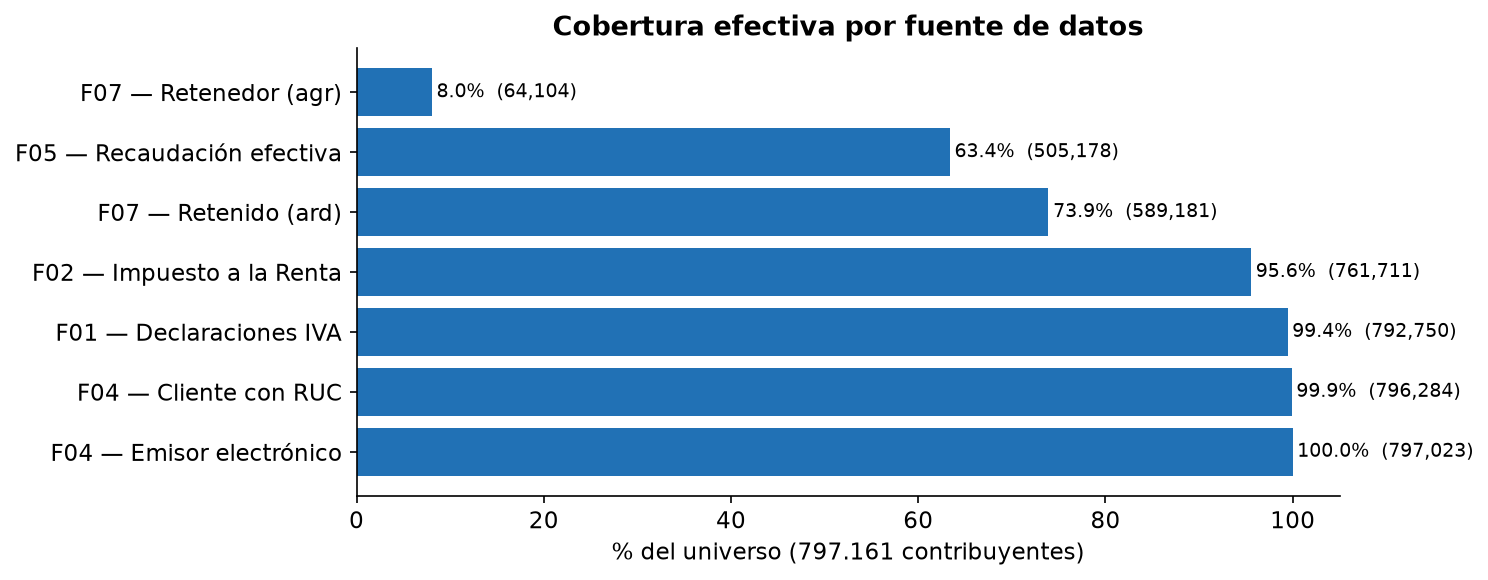

Figura guardada en outputs/


In [5]:
# Figura — cobertura por fuente
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(cob_df["Fuente"], cob_df["% universo"], color="#2171b5")
ax.set_xlabel("% del universo (797.161 contribuyentes)")
ax.set_xlim(0, 105)
for i, (n, pct) in enumerate(zip(cob_df["N contribuyentes"], cob_df["% universo"])):
    ax.text(pct + 0.5, i, f"{pct:.1f}%  ({n:,.0f})", va="center", fontsize=9)
ax.set_title("Cobertura efectiva por fuente de datos", fontweight="bold")
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig01_cobertura_por_fuente.png", bbox_inches="tight")
plt.show()
print("Figura guardada en outputs/")

## 2.4 Análisis de missings en variables de clustering

Los valores faltantes en las variables de clustering no son errores — 
reflejan la cobertura real de cada fuente y tienen interpretación 
económica directa. Se clasifican en cuatro grupos según su origen y 
la estrategia de tratamiento correspondiente.

In [6]:
# Clasificación de missings por origen y tratamiento
grupos_missing = {
    "F07-agr: cobertura 8% (solo retenedores)": [
        "tasa_efe_iva_agr", "hhi_iva_agr",
    ],
    "F05: contribuyentes sin recaudación efectiva (36.6%)": [
        "cv_reca_mensual_f05", "rezago_medio_f05", "hhi_reca_f05",
        "prop_efectivo_f05", "prop_compensa_f05", "prop_pagos_tardios_f05",
    ],
    "F07-ard: cobertura 73.9% (retenidos)": [
        "tasa_efe_iva_ard", "hhi_iva_ard",
    ],
    "F01: ratios indefinidos (denominador cero)": [
        "ratio_anul_emit", "ratio_pago_causado", "ratio_saldo_iva_vtas",
        "cv_v_grav_nta", "cv_c_grav_cdc_nta", "cv_iva_pagado",
        "cv_ret_recibidas", "ratio_imp_vtas_vtas", "ratio_nc_ventas",
        "ratio_crt_imp_cmp",
    ],
    "F02: sin declaración de renta (4.45%)": [
        "I_ingresos_avg", "margen_operativo_avg", "costos_ingresos_avg",
        "carga_efectiva_ir_avg", "gap_ret_ir_avg", "prop_anios_perdida",
    ],
    "F06: contribuyentes sin demora registrada": [
        "promedio_dias_demora", "p90_dias_demora",
        "tasa_omision_reciente", "tasa_tardio_reciente",
    ],
    "F04: sin rol emisor o cliente (0.1-0.6%)": [
        "prop_gravado_fe", "ratio_nc_fe", "prop_ventas_cf_fe",
        "hhi_clientes_fe", "prop_compras_grav_fe",
        "ratio_nc_recibidas_fe", "hhi_proveedores_fe",
    ],
    "F03: sin fecha de inicio de actividades (0.2%)": [
        "antig_actividad",
    ],
}

print("CLASIFICACIÓN DE MISSINGS EN VARIABLES DE CLUSTERING")
print("=" * 60)
total_vars_con_missing = 0
for grupo, variables in grupos_missing.items():
    pcts = [df[v].isnull().mean() * 100 for v in variables if v in df.columns]
    if pcts:
        print(f"\n{grupo}")
        print(f"  Variables : {len(pcts)}")
        print(f"  Missing   : {min(pcts):.1f}% – {max(pcts):.1f}%")
        total_vars_con_missing += len(pcts)
print(f"\nTotal variables con missing: {total_vars_con_missing} de {len(config.CLUSTER_VARS)}")

CLASIFICACIÓN DE MISSINGS EN VARIABLES DE CLUSTERING

F07-agr: cobertura 8% (solo retenedores)
  Variables : 2
  Missing   : 92.9% – 92.9%

F05: contribuyentes sin recaudación efectiva (36.6%)
  Variables : 6
  Missing   : 38.9% – 52.6%

F07-ard: cobertura 73.9% (retenidos)
  Variables : 2
  Missing   : 46.3% – 48.1%

F01: ratios indefinidos (denominador cero)
  Variables : 10
  Missing   : 6.6% – 45.5%

F02: sin declaración de renta (4.45%)
  Variables : 6
  Missing   : 4.4% – 21.1%

F06: contribuyentes sin demora registrada
  Variables : 4
  Missing   : 1.1% – 3.0%

F04: sin rol emisor o cliente (0.1-0.6%)
  Variables : 7
  Missing   : 0.1% – 30.3%

F03: sin fecha de inicio de actividades (0.2%)
  Variables : 1
  Missing   : 0.2% – 0.2%

Total variables con missing: 38 de 80


### Estrategia de tratamiento de missings

| Grupo | Tratamiento | Justificación |
|---|---|---|
| F07-agr (92.9%) | Imputar 0 | Ausencia = no actúa como retenedor |
| F05 ratios (38.9%) | Imputar 0 | Ausencia = sin recaudación efectiva |
| F07-ard (46-48%) | Imputar 0 | Ausencia = no fue retenido |
| F01 ratios (6-45%) | Imputar 0 | Denominador cero = comportamiento nulo |
| F02 (4.45%) | Mantener missing → imputar mediana | Sin declaración de renta: valor desconocido, no cero |
| F06 demora (1-3%) | Imputar 0 | Sin demora registrada = cumplimiento puntual |
| F04 (0.1-0.6%) | Imputar 0 | Sin rol en red electrónica = participación nula |
| F03 antigüedad (0.2%) | Imputar mediana | Fecha no registrada en catastro |

La distinción clave es entre **ausencia que significa cero** 
(no actúa como retenedor → tasa de retención = 0) y 
**ausencia que significa desconocido** (no declaró renta → ingreso desconocido, 
no necesariamente cero).

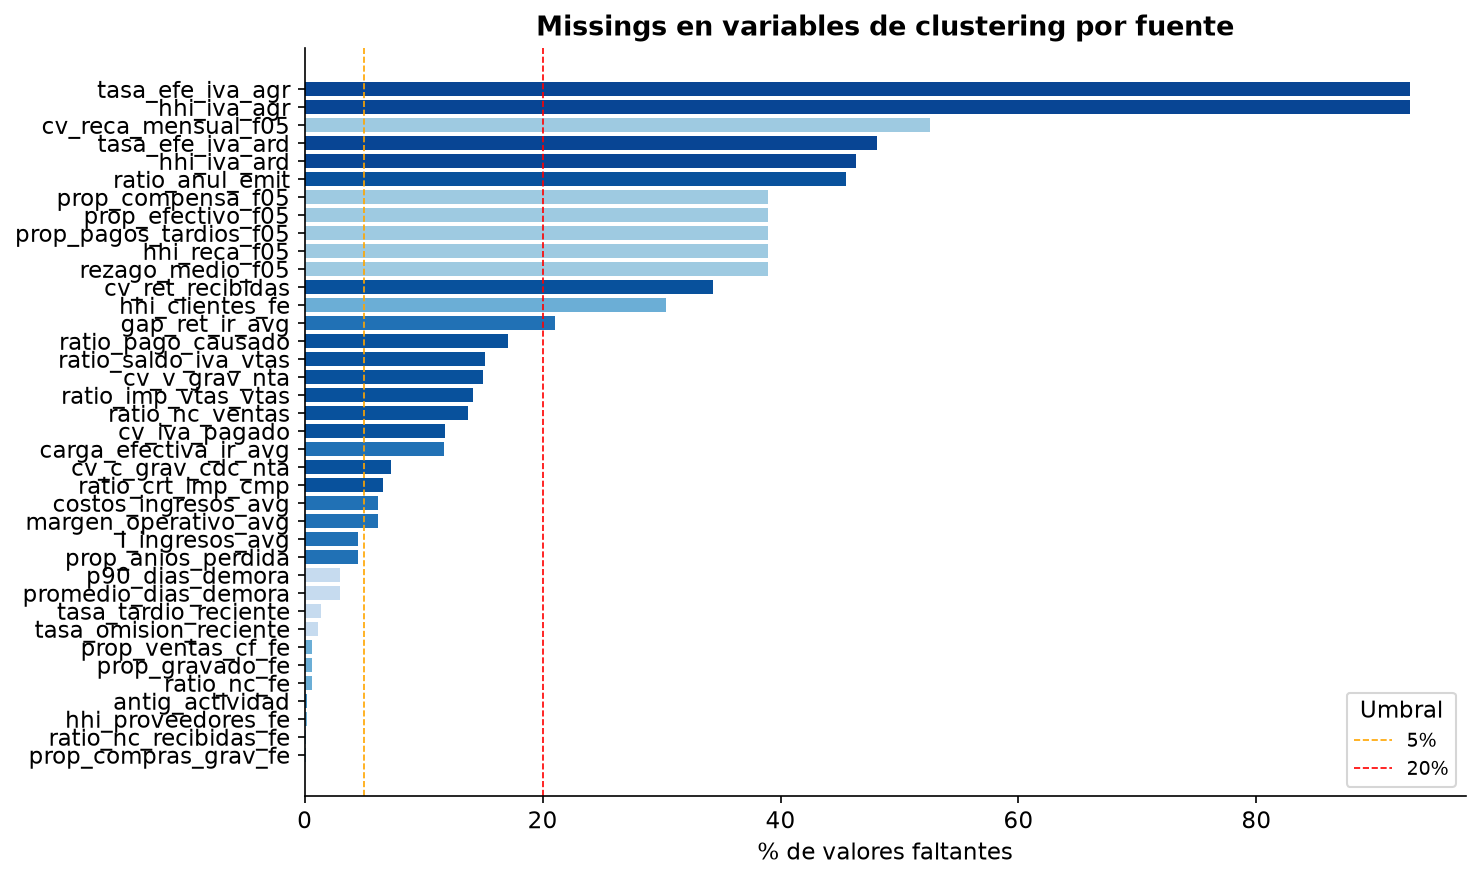

Figura guardada en outputs/


In [7]:
# Figura — mapa de missings por grupo de fuente
fig, ax = plt.subplots(figsize=(10, 6))

miss_plot = (df[config.CLUSTER_VARS]
             .isnull()
             .mean()
             .mul(100)
             .reset_index()
             .rename(columns={"index": "variable", 0: "pct_missing"}))

# Colorear por fuente
fuente_color = {}
for v in config.F01_VARS: fuente_color[v] = "#08519c"
for v in config.F02_VARS: fuente_color[v] = "#2171b5"
for v in config.F03_VARS: fuente_color[v] = "#4292c6"
for v in config.F04_VARS: fuente_color[v] = "#6baed6"
for v in config.F05_VARS: fuente_color[v] = "#9ecae1"
for v in config.F06_VARS: fuente_color[v] = "#c6dbef"
for v in config.F07_VARS: fuente_color[v] = "#084594"

miss_plot = miss_plot[miss_plot["pct_missing"] > 0].sort_values(
    "pct_missing", ascending=True)
colores = [fuente_color.get(v, "#999999") for v in miss_plot["variable"]]

ax.barh(miss_plot["variable"], miss_plot["pct_missing"], color=colores)
ax.axvline(x=5,  color="orange", linestyle="--", linewidth=0.8, label="5%")
ax.axvline(x=20, color="red",    linestyle="--", linewidth=0.8, label="20%")
ax.set_xlabel("% de valores faltantes")
ax.set_title("Missings en variables de clustering por fuente", fontweight="bold")
ax.legend(title="Umbral", fontsize=9)
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig02_missings_clustering.png", bbox_inches="tight")
plt.show()
print("Figura guardada en outputs/")

## 2.5 Distribuciones de variables de clustering

Se analizan las distribuciones de las 80 variables de clustering 
organizadas por fuente. Para cada grupo se reportan estadísticos 
descriptivos clave y se identifican los casos que requieren 
transformación logarítmica antes de la estandarización.

### 2.5.1 F01 — Comportamiento declarativo IVA (42 variables)

In [8]:
# Estadísticos descriptivos F01
desc_f01 = (df[config.F01_VARS]
            .describe(percentiles=[.25, .50, .75, .95, .99])
            .T
            .round(2))
desc_f01["skewness"] = df[config.F01_VARS].skew().round(3)
desc_f01["% missing"] = (df[config.F01_VARS].isnull().mean() * 100).round(2)

# Mostrar solo columnas clave
cols_show = ["count", "mean", "50%", "95%", "99%", "max", "skewness", "% missing"]
display(desc_f01[cols_show].style.format("{:.2f}"))

,count,mean,50%,95%,99%,max,skewness,% missing
tot_v_grav_nta,797161.00,779012.33,18002.30,1146400.30,7996502.22,8042721778.29,164.95,0.00
tot_v_grav_brt,797161.00,839094.82,18578.57,1187380.85,8487621.27,8930016203.86,167.53,0.00
tot_imp_v_grav,797161.00,100688.27,2395.45,149378.95,1028660.27,1041408699.01,166.38,0.00
tot_v_tc_cdc,797161.00,274481.84,0.00,73263.68,1128021.69,7187190713.66,253.17,0.00
tot_v_tc_sdc,797161.00,385700.98,3266.25,580266.69,3989147.04,6364691029.23,230.40,0.00
tot_c_grav_cdc_nta,797161.00,644601.94,20968.85,910322.21,6656131.58,6529424947.89,171.84,0.00
tot_imp_c_cdc,797161.00,83338.66,2766.23,118185.58,856595.59,845781799.78,173.18,0.00
tot_c_tc_iaf,797161.00,392074.28,3559.96,475920.06,4032537.42,4879383581.45,185.35,0.00
tot_crt_aplicable,797161.00,77816.86,1304.93,105887.11,798375.36,845884395.27,176.21,0.00
tot_iva_causado,797161.00,34754.10,1078.79,68704.24,377001.57,365973278.87,196.49,0.00


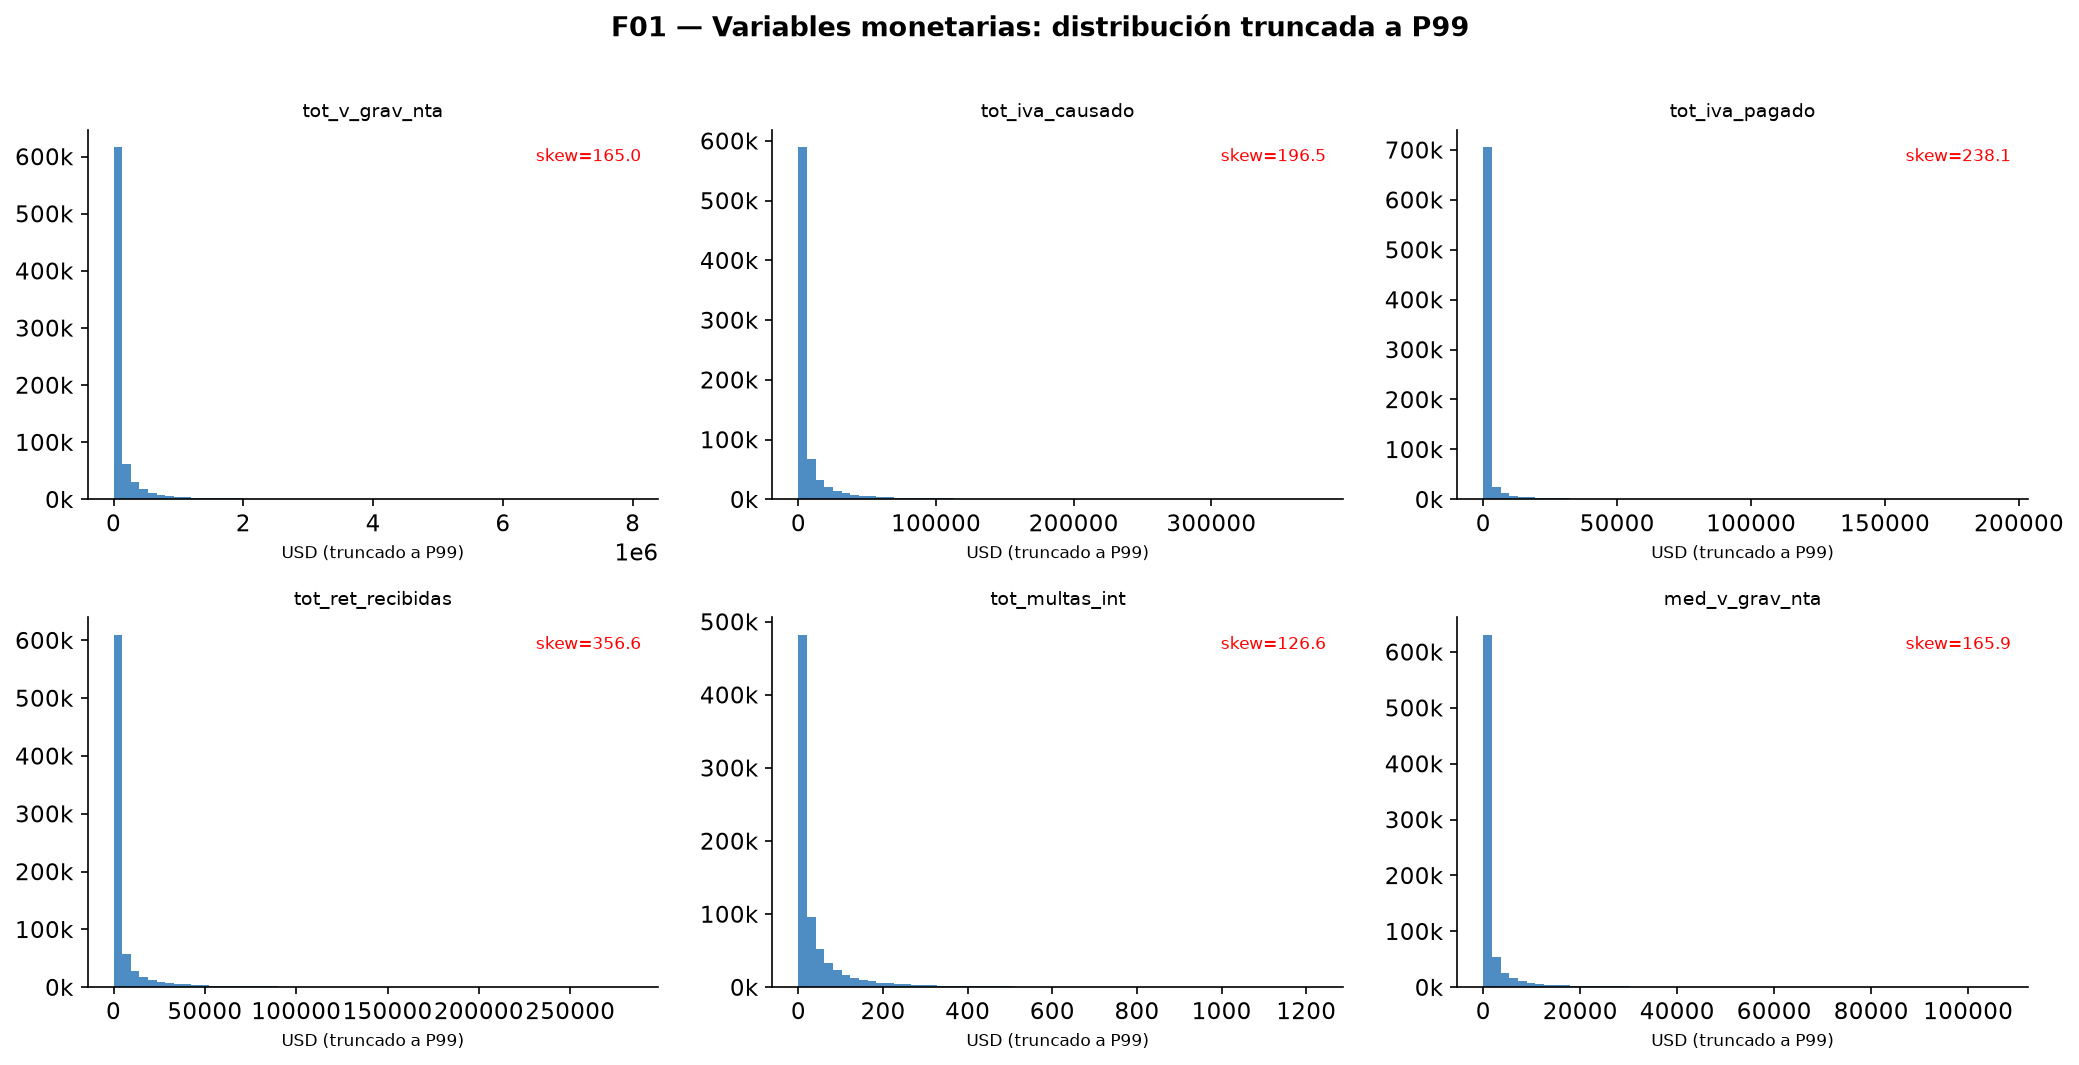

In [9]:
# Figura — distribución de variables monetarias F01 (las de mayor skewness)
vars_monetarias = [
    "tot_v_grav_nta", "tot_iva_causado", "tot_iva_pagado",
    "tot_ret_recibidas", "tot_multas_int", "med_v_grav_nta",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, v in enumerate(vars_monetarias):
    data = df[v].dropna()
    # Truncar al P99 para visualización
    p99 = data.quantile(0.99)
    data_plot = data[data <= p99]
    axes[i].hist(data_plot, bins=60, color="#2171b5", alpha=0.8, edgecolor="none")
    axes[i].set_title(v, fontsize=9)
    axes[i].set_xlabel("USD (truncado a P99)", fontsize=8)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1000:.0f}k"))
    sk = df[v].skew()
    axes[i].text(0.97, 0.95, f"skew={sk:.1f}",
                 transform=axes[i].transAxes,
                 ha="right", va="top", fontsize=8, color="red")

fig.suptitle("F01 — Variables monetarias: distribución truncada a P99",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig03_f01_monetarias_dist.png", bbox_inches="tight")
plt.show()

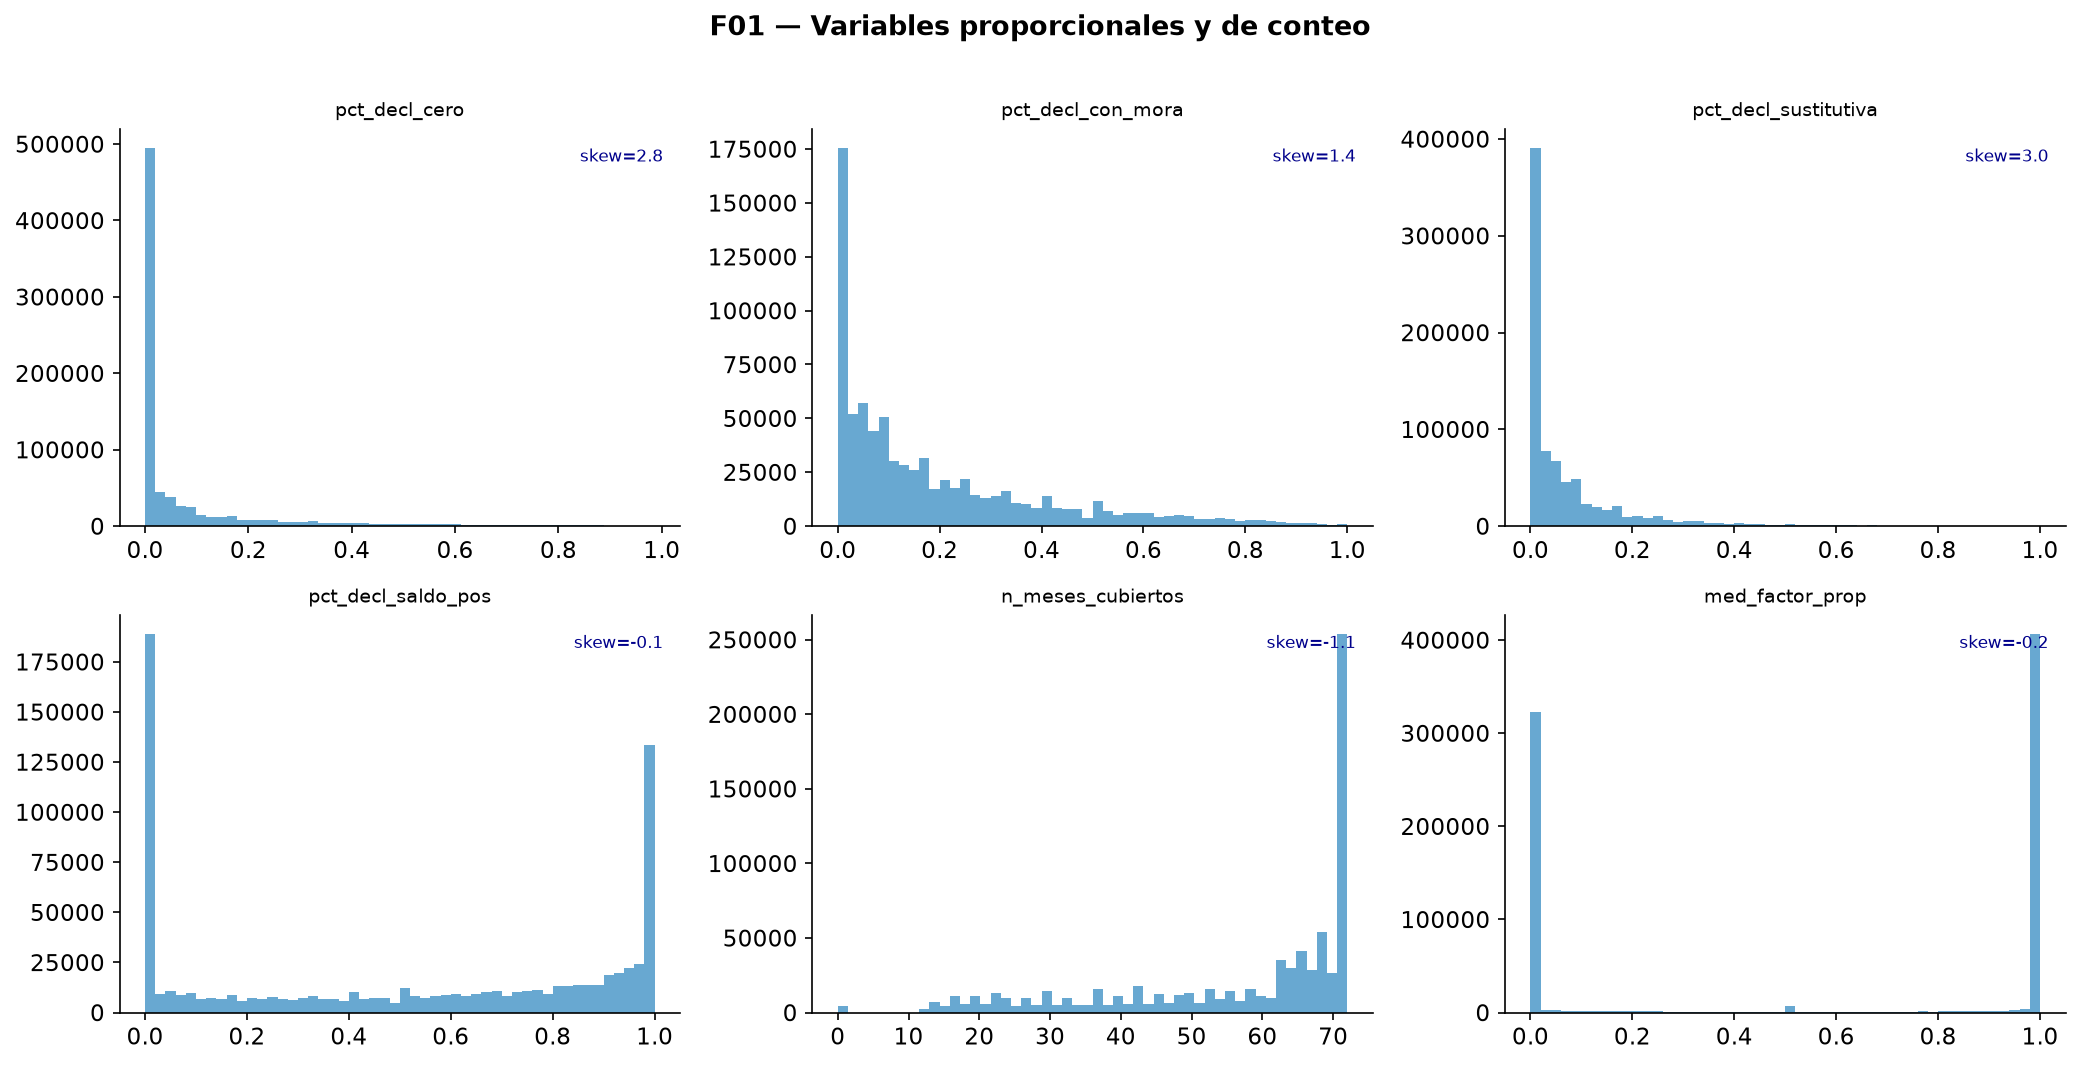

In [10]:
# Figura — variables proporcionales y de conteo F01
vars_prop = [
    "pct_decl_cero", "pct_decl_con_mora", "pct_decl_sustitutiva",
    "pct_decl_saldo_pos", "n_meses_cubiertos", "med_factor_prop",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, v in enumerate(vars_prop):
    data = df[v].dropna()
    axes[i].hist(data, bins=50, color="#4292c6", alpha=0.8, edgecolor="none")
    axes[i].set_title(v, fontsize=9)
    sk = data.skew()
    axes[i].text(0.97, 0.95, f"skew={sk:.1f}",
                 transform=axes[i].transAxes,
                 ha="right", va="top", fontsize=8, color="darkblue")

fig.suptitle("F01 — Variables proporcionales y de conteo",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig04_f01_proporcionales_dist.png", bbox_inches="tight")
plt.show()

### 2.5.2 F02 a F07 — Variables complementarias (38 variables)

In [11]:
# Estadísticos descriptivos F02 a F07
vars_f02_f07 = (config.F02_VARS + config.F03_VARS + config.F04_VARS +
                config.F05_VARS + config.F06_VARS + config.F07_VARS)

desc_resto = (df[vars_f02_f07]
              .describe(percentiles=[.25, .50, .75, .95, .99])
              .T
              .round(3))
desc_resto["skewness"] = df[vars_f02_f07].skew().round(3)
desc_resto["% missing"] = (df[vars_f02_f07].isnull().mean() * 100).round(2)

cols_show = ["count", "mean", "50%", "95%", "99%", "max", "skewness", "% missing"]
display(desc_resto[cols_show].style.format("{:.3f}"))

,count,mean,50%,95%,99%,max,skewness,% missing
I_ingresos_avg,761711.000,141941.397,17354.077,465749.460,2929314.413,8308696.810,9.067,4.450
margen_operativo_avg,747741.000,0.405,0.356,0.998,1.000,1.000,0.421,6.200
costos_ingresos_avg,747738.000,0.906,0.714,2.732,5.990,16.362,4.847,6.200
carga_efectiva_ir_avg,704015.000,0.424,0.008,0.782,10.326,84.585,14.238,11.680
gap_ret_ir_avg,629246.000,0.275,0.419,1.000,1.000,1.000,-0.545,21.060
prop_anios_perdida,761711.000,0.173,0.000,0.750,1.000,1.000,1.551,4.450
antig_actividad,795432.000,14.989,13.777,30.166,42.998,55.997,0.793,0.220
n_establ_total,797161.000,1.653,1.000,4.000,6.000,1714.000,201.905,0.000
tasa_cierre_establ,797161.000,0.177,0.000,1.000,1.000,1.000,1.547,0.000
n_cierres_24m,797161.000,0.149,0.000,1.000,2.000,728.000,410.118,0.000


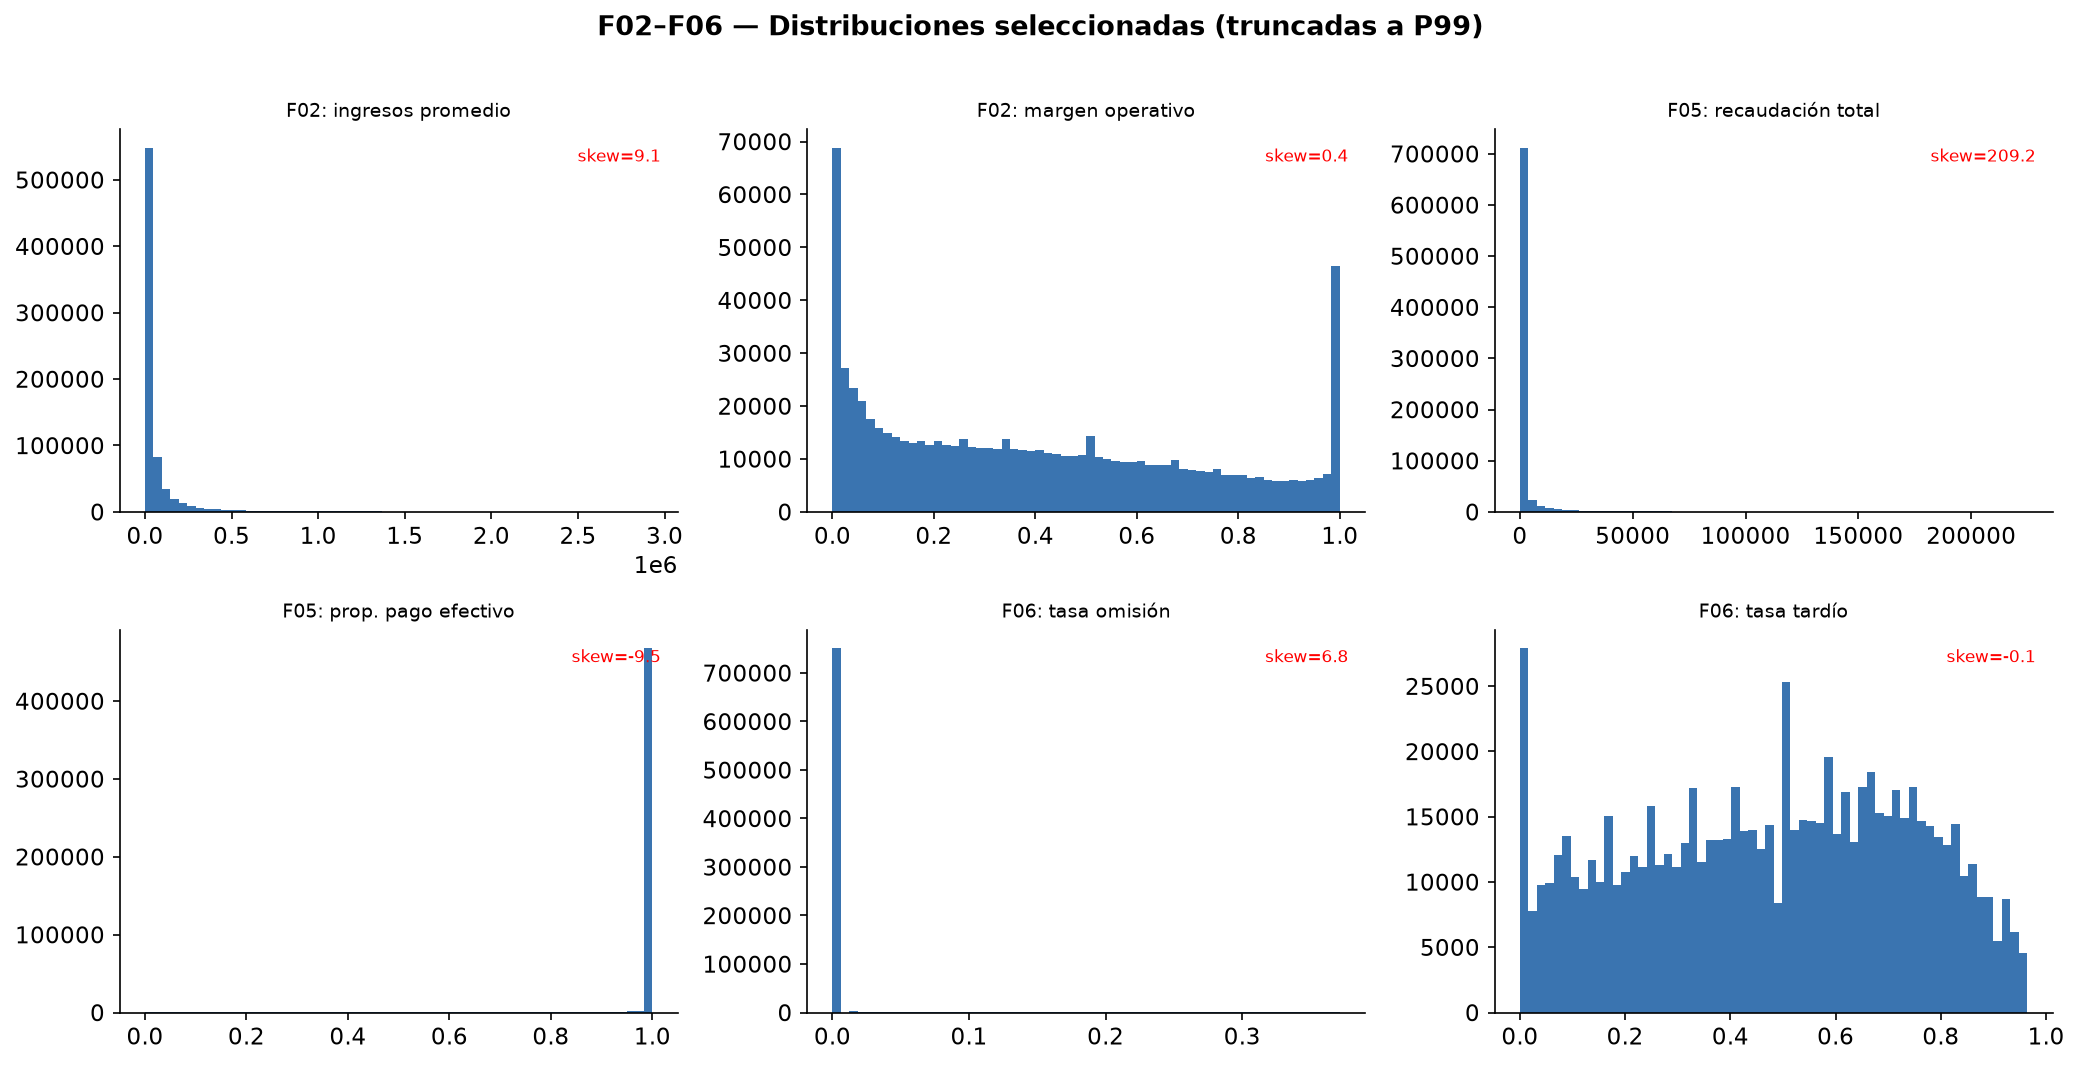

In [12]:
# Figura — distribuciones F02 a F07 (variables con skewness notable)
vars_plot = [
    "I_ingresos_avg", "margen_operativo_avg",
    "reca_total_f05", "prop_efectivo_f05",
    "tasa_omision", "tasa_tardio",
]
etiquetas = ["F02: ingresos promedio", "F02: margen operativo",
             "F05: recaudación total", "F05: prop. pago efectivo",
             "F06: tasa omisión", "F06: tasa tardío"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, (v, lbl) in enumerate(zip(vars_plot, etiquetas)):
    data = df[v].dropna()
    p99  = data.quantile(0.99)
    data_plot = data[data <= p99]
    axes[i].hist(data_plot, bins=60, color="#08519c", alpha=0.8, edgecolor="none")
    axes[i].set_title(lbl, fontsize=9)
    sk = data.skew()
    axes[i].text(0.97, 0.95, f"skew={sk:.1f}",
                 transform=axes[i].transAxes,
                 ha="right", va="top", fontsize=8, color="red")

fig.suptitle("F02–F06 — Distribuciones seleccionadas (truncadas a P99)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig05_f02f06_dist.png", bbox_inches="tight")
plt.show()

### 2.5.3 Decisiones de transformación confirmadas por el EDA

El análisis de distribuciones confirma tres grupos de tratamiento 
para las variables de clustering antes de la estandarización:

**Grupo A — Log(x+1) obligatorio** (skewness > 10): todas las variables 
monetarias de F01, `I_ingresos_avg`, `carga_efectiva_ir_avg`, 
`reca_total_f05`, `n_establ_total`, `n_cierres_24m`, `n_aperturas_24m`.

**Grupo B — Winsorización P99 + Log(x+1)**: `ratio_anul_emit`, 
`ratio_pago_causado`, `ratio_saldo_iva_vtas`. Presentan valores 
extremos por denominadores cercanos a cero — se winsorizan primero 
para eliminar artefactos contables y luego se aplica log.

**Grupo C — Directo a z-score** (skewness < 2 en valor absoluto): 
`med_factor_prop`, `ratio_crt_imp_cmp`, `cv_iva_pagado`, 
`pct_decl_saldo_pos`, `n_meses_cubiertos`, variables de F06 
(tasas acotadas a [0,1]).

In [13]:
# Actualizar config con las decisiones de transformación confirmadas por EDA
# Grupo B — winsorizar ANTES de log (ratios con denominadores cercanos a cero)
WINSOR_ANTES_LOG = {
    "ratio_anul_emit"    : df["ratio_anul_emit"].quantile(0.99),
    "ratio_pago_causado" : df["ratio_pago_causado"].quantile(0.99),
    "ratio_saldo_iva_vtas": df["ratio_saldo_iva_vtas"].quantile(0.99),
}

# Grupo C — directo a z-score (no necesitan log)
NO_LOG_VARS = [
    "med_factor_prop", "ratio_crt_imp_cmp", "cv_v_grav_nta",
    "cv_c_grav_cdc_nta", "cv_iva_pagado", "cv_ret_recibidas",
    "n_anos_con_vtas", "n_anos_con_exp_tc_cdc", "n_anos_con_compras",
    "n_anos_con_retenedor", "n_anos_con_iva_pagado", "n_meses_cubiertos",
    "pct_decl_cero", "pct_decl_sustitutiva", "pct_decl_con_mora",
    "pct_decl_anul_alta", "pct_decl_nc_alta", "pct_decl_saldo_pos",
    "ratio_nc_ventas", "ratio_imp_vtas_vtas",
    # F06 — tasas acotadas [0,1]
    "tasa_omision", "tasa_tardio", "tasa_omision_reciente", "tasa_tardio_reciente",
    "promedio_dias_demora", "p90_dias_demora",
    # F02 — proporciones y ratios acotados
    "margen_operativo_avg", "gap_ret_ir_avg", "prop_anios_perdida",
    # F04 — proporciones acotadas [0,1]
    "prop_gravado_fe", "prop_ventas_cf_fe", "prop_compras_grav_fe",
    "hhi_clientes_fe", "hhi_proveedores_fe",
    "ratio_nc_fe", "ratio_nc_recibidas_fe",
    # F05 — proporciones acotadas [0,1]
    "prop_efectivo_f05", "prop_compensa_f05", "prop_pagos_tardios_f05",
    "hhi_reca_f05", "cv_reca_mensual_f05",
    # F07 — tasas y HHI acotados
    "tasa_efe_iva_agr", "hhi_iva_agr", "tasa_efe_iva_ard", "hhi_iva_ard",
]

print("Umbrales de winsorización para ratios con denominador cercano a cero:")
for v, umbral in WINSOR_ANTES_LOG.items():
    print(f"  {v:30s} P99 = {umbral:,.4f}")

print(f"\nVariables que van directo a z-score (sin log): {len(NO_LOG_VARS)}")
print(f"Variables que requieren log(x+1)            : "
      f"{len(config.CLUSTER_VARS) - len(NO_LOG_VARS)}")

Umbrales de winsorización para ratios con denominador cercano a cero:
  ratio_anul_emit                P99 = 0.9286
  ratio_pago_causado             P99 = 96.7939
  ratio_saldo_iva_vtas           P99 = 31.4766

Variables que van directo a z-score (sin log): 45
Variables que requieren log(x+1)            : 35


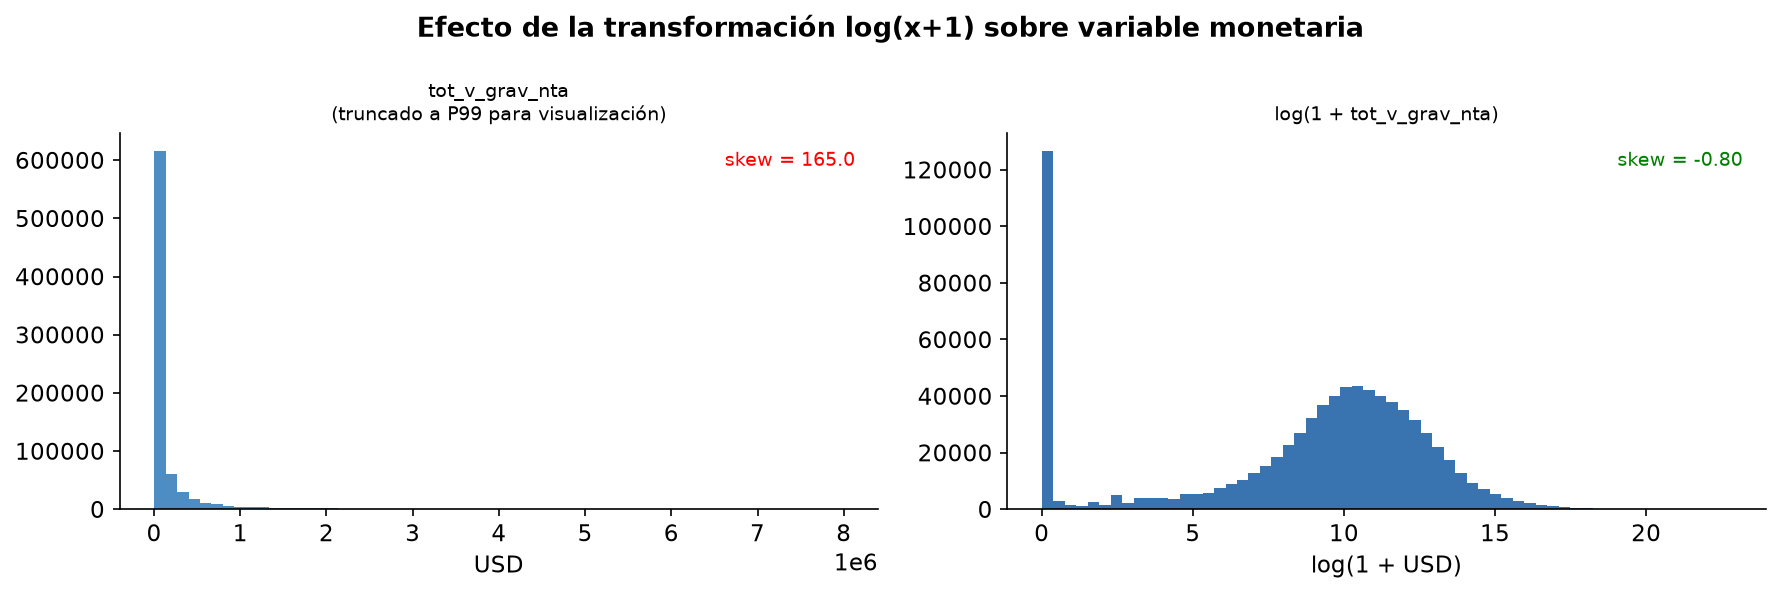

In [14]:
# Figura — efecto de log(x+1) en variable monetaria representativa
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

v = "tot_v_grav_nta"
data = df[v].dropna()
p99  = data.quantile(0.99)

# Original truncada a P99
axes[0].hist(data[data <= p99], bins=60,
             color="#2171b5", alpha=0.8, edgecolor="none")
axes[0].set_title(f"{v}\n(truncado a P99 para visualización)", fontsize=9)
axes[0].set_xlabel("USD")
axes[0].text(0.97, 0.95, f"skew = {data.skew():.1f}",
             transform=axes[0].transAxes,
             ha="right", va="top", fontsize=9, color="red")

# Transformada
data_log = np.log1p(data)
axes[1].hist(data_log, bins=60,
             color="#08519c", alpha=0.8, edgecolor="none")
axes[1].set_title(f"log(1 + {v})", fontsize=9)
axes[1].set_xlabel("log(1 + USD)")
axes[1].text(0.97, 0.95, f"skew = {data_log.skew():.2f}",
             transform=axes[1].transAxes,
             ha="right", va="top", fontsize=9, color="green")

fig.suptitle("Efecto de la transformación log(x+1) sobre variable monetaria",
             fontweight="bold")
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig06_efecto_log_transform.png", bbox_inches="tight")
plt.show()

## 2.6 Análisis de correlaciones

Se analiza la estructura de correlaciones entre las variables de 
clustering para identificar redundancias adicionales a las ya 
detectadas en el Log16. Se trabaja sobre las variables transformadas 
(log donde corresponde, winsorización previa en Grupo B) para que 
la correlación refleje la relación real y no el efecto de outliers.

In [15]:
import importlib
importlib.reload(config)
print("config.py recargado")
print(f"WINSOR_ANTES_LOG : {config.WINSOR_ANTES_LOG}")
print(f"NO_LOG_VARS      : {len(config.NO_LOG_VARS)} variables")

config.py recargado
WINSOR_ANTES_LOG : {'ratio_anul_emit': 0.9286, 'ratio_pago_causado': 96.7939, 'ratio_saldo_iva_vtas': 31.4766}
NO_LOG_VARS      : 45 variables


In [16]:
# Construir versión transformada de las variables de clustering para correlaciones
df_trans = df[config.CLUSTER_VARS].copy()

# Grupo B — winsorizar primero
for v, umbral in config.WINSOR_ANTES_LOG.items():
    if v in df_trans.columns:
        df_trans[v] = df_trans[v].clip(upper=umbral)

# Winsorización F04 (confirmada en Log16)
for v, umbral in config.WINSOR_PARAMS.items():
    if v in df_trans.columns:
        df_trans[v] = df_trans[v].clip(upper=umbral)

# Log(x+1) a las variables que no están en NO_LOG_VARS
log_vars = [v for v in config.CLUSTER_VARS if v not in config.NO_LOG_VARS]
for v in log_vars:
    if v in df_trans.columns:
        df_trans[v] = np.log1p(df_trans[v].clip(lower=0))

print(f"Variables transformadas para correlación:")
print(f"  Log(x+1) aplicado a : {len(log_vars)} variables")
print(f"  Directo (sin log)    : {len(config.NO_LOG_VARS)} variables")
print(f"  Total                : {len(config.CLUSTER_VARS)} variables")

Variables transformadas para correlación:
  Log(x+1) aplicado a : 35 variables
  Directo (sin log)    : 45 variables
  Total                : 80 variables


In [17]:
# Matriz de correlación completa — Spearman (más robusta que Pearson con asimetría)
corr_matrix = df_trans.corr(method="spearman", numeric_only=True)

# Pares con correlación alta (|r| > 0.80) — candidatos a eliminar
umbral_corr = 0.80
corr_pairs = (corr_matrix
              .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
              .stack()
              .reset_index())
corr_pairs.columns = ["var1", "var2", "spearman_r"]
corr_pairs["abs_r"] = corr_pairs["spearman_r"].abs()
alta_corr = (corr_pairs[corr_pairs["abs_r"] >= umbral_corr]
             .sort_values("abs_r", ascending=False)
             .reset_index(drop=True))

print(f"Pares con correlación Spearman |r| ≥ {umbral_corr}: {len(alta_corr)}")
print()
display(alta_corr.style.format({
    "spearman_r": "{:.4f}",
    "abs_r"     : "{:.4f}"
}))

Pares con correlación Spearman |r| ≥ 0.8: 35



,var1,var2,spearman_r,abs_r
0,tot_c_grav_cdc_nta,tot_imp_c_cdc,0.9995,0.9995
1,tot_v_grav_nta,tot_imp_v_grav,0.9993,0.9993
2,tot_v_grav_nta,tot_v_grav_brt,0.9968,0.9968
3,tot_v_grav_brt,tot_imp_v_grav,0.9961,0.9961
4,tot_v_tc_cdc,n_anos_con_exp_tc_cdc,0.9889,0.9889
5,tot_iva_total_pagar,reca_total_f05,0.9748,0.9748
6,tasa_omision,tasa_omision_reciente,0.9737,0.9737
7,promedio_dias_demora,p90_dias_demora,0.9688,0.9688
8,tot_imp_v_grav,tot_iva_causado,0.9602,0.9602
9,tot_v_grav_nta,tot_iva_causado,0.9594,0.9594


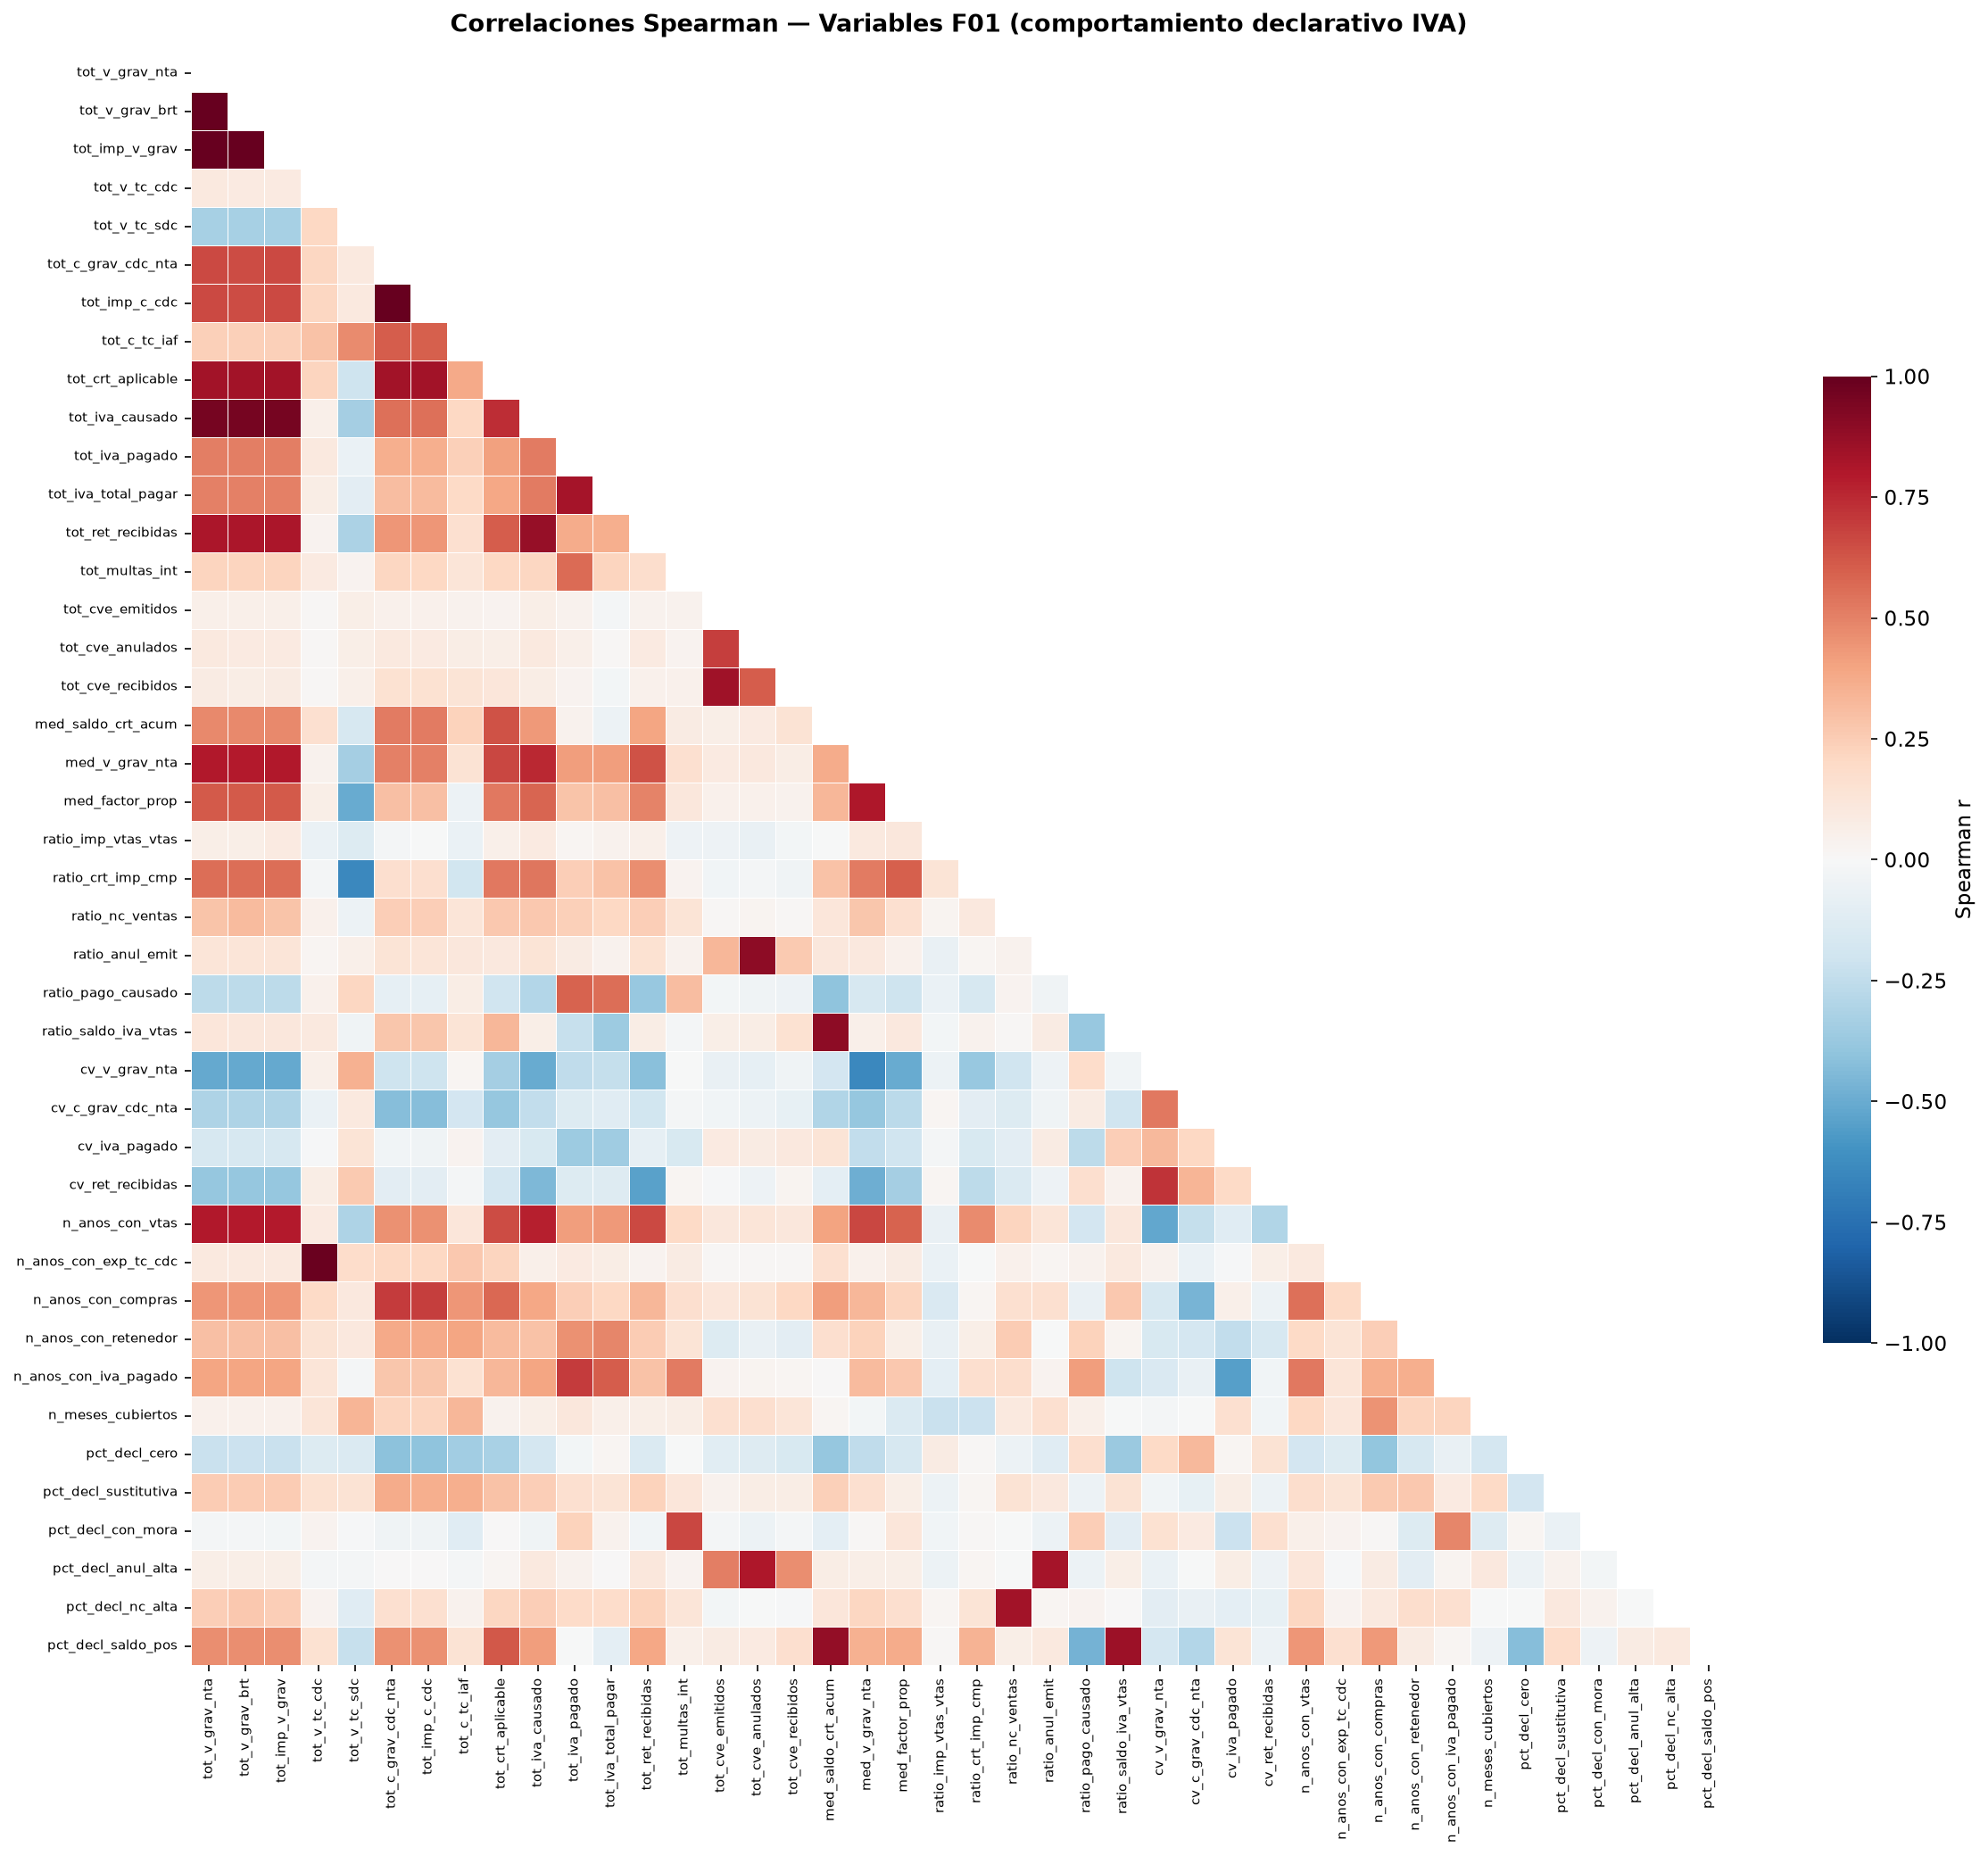

In [18]:
# Figura — heatmap de correlaciones por bloque de fuente
# Para legibilidad se muestra solo el bloque F01 (42 vars)
corr_f01 = df_trans[config.F01_VARS].corr(method="spearman")

mask = np.triu(np.ones_like(corr_f01, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    corr_f01,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot=False,
    ax=ax,
    cbar_kws={"shrink": 0.6, "label": "Spearman r"},
)
ax.set_title("Correlaciones Spearman — Variables F01 (comportamiento declarativo IVA)",
             fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig07_corr_f01_heatmap.png", bbox_inches="tight")
plt.show()

# Figura — heatmap bloque F02 a F07
vars_f02_f07 = (config.F02_VARS + config.F03_VARS + config.F04_VARS +
                config.F05_VARS + config.F06_VARS + config.F07_VARS)
corr_resto = df_trans[vars_f02_f07].corr(method="spearman")

mask2 = np.triu(np.ones_like(corr_resto, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_resto,
    mask=mask2,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    ax=ax,
    cbar_kws={"shrink": 0.6, "label": "Spearman r"},
)
ax.set_title("Correlaciones Spearman — Variables F02 a F07",
             fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=90, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig08_corr_f02f07_heatmap.png", bbox_inches="tight")
plt.show()

## 2.7 Decisiones de reducción por redundancia

El análisis de correlaciones Spearman identifica 35 pares con |r| ≥ 0.80.
Se clasifican en cuatro grupos según su naturaleza y se decide qué variable 
retener en cada caso.

In [19]:
# Decisiones de eliminación por redundancia
# Criterio: ante dos variables altamente correlacionadas, se retiene
# la de mayor interpretabilidad económica directa o menor % de missing.

eliminadas = {

    # GRUPO 1 — Redundancia contable perfecta dentro de F01
    # tot_v_grav_brt = tot_v_grav_nta + exportaciones; r=0.997
    # tot_imp_v_grav = tot_v_grav_nta * tarifa; r=0.999
    # Se retiene tot_v_grav_nta (base neta, más directa)
    "tot_v_grav_brt"  : "r=0.997 con tot_v_grav_nta (redundancia contable)",
    "tot_imp_v_grav"  : "r=0.999 con tot_v_grav_nta (tot_imp = nta × tarifa)",

    # tot_imp_c_cdc = tot_c_grav_cdc_nta × tarifa; r=0.9995
    "tot_imp_c_cdc"   : "r=0.9995 con tot_c_grav_cdc_nta (redundancia contable)",

    # GRUPO 2 — Redundancia temporal (versión reciente vs. total)
    # tasa_omision_reciente r=0.974 con tasa_omision
    # tasa_tardio_reciente r=0.906 con tasa_tardio
    # Se retienen las versiones totales (mayor cobertura temporal 2020-2025)
    # Las versiones recientes pasan a caracterización post-clustering
    "tasa_omision_reciente" : "r=0.974 con tasa_omision → a CHARAC_VARS",
    "tasa_tardio_reciente"  : "r=0.906 con tasa_tardio  → a CHARAC_VARS",

    # GRUPO 3 — Redundancia métricas de demora
    # p90_dias_demora r=0.969 con promedio_dias_demora
    # Se retiene promedio (más estable, menor sensibilidad a outliers extremos)
    "p90_dias_demora" : "r=0.969 con promedio_dias_demora",

    # GRUPO 4 — Redundancia entre ratio y su componente de conteo
    # n_anos_con_exp_tc_cdc r=0.989 con tot_v_tc_cdc
    # Se retiene tot_v_tc_cdc (magnitud, más informativa para clustering)
    "n_anos_con_exp_tc_cdc" : "r=0.989 con tot_v_tc_cdc",

    # GRUPO 5 — Redundancia entre saldo y proporción de saldo
    # ratio_saldo_iva_vtas r=0.895 con med_saldo_crt_acum
    # pct_decl_saldo_pos r=0.880 con med_saldo_crt_acum
    # Se retiene med_saldo_crt_acum (magnitud acumulada) y pct_decl_saldo_pos
    # (comportamiento frecuencia); se elimina ratio_saldo_iva_vtas
    "ratio_saldo_iva_vtas"  : "r=0.895 con med_saldo_crt_acum (redundante con magnitud)",

    # GRUPO 6 — Redundancia entre anulaciones y proporción de anulaciones
    # ratio_anul_emit r=0.893 con tot_cve_anulados; r=0.834 con pct_decl_anul_alta
    # Se retiene pct_decl_anul_alta (comportamiento) y tot_cve_anulados (magnitud)
    # Se elimina ratio_anul_emit (capturado por ambas)
    "ratio_anul_emit"       : "r=0.893 con tot_cve_anulados + r=0.834 con pct_decl_anul_alta",

    # GRUPO 7 — Redundancia F02: margen y ratio costos son inversos
    # margen_operativo_avg r=-0.895 con costos_ingresos_avg
    # Se retiene margen_operativo_avg (más intuitivo económicamente)
    "costos_ingresos_avg"   : "r=-0.895 con margen_operativo_avg (inverso matemático)",

    # GRUPO 8 — Redundancia actividades y secciones CIIU
    # n_secciones_ciiu r=0.813 con n_actividades_unicas_ruc
    # Se retiene n_actividades_unicas_ruc (mayor granularidad)
    "n_secciones_ciiu"      : "r=0.813 con n_actividades_unicas_ruc",
}

print("VARIABLES ELIMINADAS DEL NÚCLEO DE CLUSTERING POR REDUNDANCIA")
print("=" * 65)
for v, razon in eliminadas.items():
    print(f"  {v:<30s}  {razon}")

print(f"\nTotal eliminadas: {len(eliminadas)}")
print(f"Variables núcleo originales : {len(config.CLUSTER_VARS)}")
print(f"Variables núcleo depuradas  : {len(config.CLUSTER_VARS) - len(eliminadas)}")

VARIABLES ELIMINADAS DEL NÚCLEO DE CLUSTERING POR REDUNDANCIA
  tot_v_grav_brt                  r=0.997 con tot_v_grav_nta (redundancia contable)
  tot_imp_v_grav                  r=0.999 con tot_v_grav_nta (tot_imp = nta × tarifa)
  tot_imp_c_cdc                   r=0.9995 con tot_c_grav_cdc_nta (redundancia contable)
  tasa_omision_reciente           r=0.974 con tasa_omision → a CHARAC_VARS
  tasa_tardio_reciente            r=0.906 con tasa_tardio  → a CHARAC_VARS
  p90_dias_demora                 r=0.969 con promedio_dias_demora
  n_anos_con_exp_tc_cdc           r=0.989 con tot_v_tc_cdc
  ratio_saldo_iva_vtas            r=0.895 con med_saldo_crt_acum (redundante con magnitud)
  ratio_anul_emit                 r=0.893 con tot_cve_anulados + r=0.834 con pct_decl_anul_alta
  costos_ingresos_avg             r=-0.895 con margen_operativo_avg (inverso matemático)
  n_secciones_ciiu                r=0.813 con n_actividades_unicas_ruc

Total eliminadas: 11
Variables núcleo originales : 80
V

In [20]:
# Construir lista definitiva de variables de clustering
CLUSTER_VARS_FINAL = [v for v in config.CLUSTER_VARS if v not in eliminadas]

# Variables que pasan a caracterización
A_CHARAC = ["tasa_omision_reciente", "tasa_tardio_reciente",
            "ratio_saldo_iva_vtas", "ratio_anul_emit", "costos_ingresos_avg"]

print(f"CLUSTER_VARS_FINAL : {len(CLUSTER_VARS_FINAL)} variables")
print()

# Verificar que no queden pares problemáticos
corr_final = df_trans[CLUSTER_VARS_FINAL].corr(method="spearman", numeric_only=True)
corr_pairs_final = (corr_final
                    .where(np.triu(np.ones(corr_final.shape), k=1).astype(bool))
                    .stack()
                    .reset_index())
corr_pairs_final.columns = ["var1", "var2", "spearman_r"]
corr_pairs_final["abs_r"] = corr_pairs_final["spearman_r"].abs()
alta_final = corr_pairs_final[corr_pairs_final["abs_r"] >= 0.80].sort_values(
    "abs_r", ascending=False)

print(f"Pares con |r| ≥ 0.80 tras depuración: {len(alta_final)}")
if not alta_final.empty:
    display(alta_final.style.format({"spearman_r": "{:.4f}", "abs_r": "{:.4f}"}))
else:
    print("Sin redundancias adicionales detectadas.")

CLUSTER_VARS_FINAL : 69 variables

Pares con |r| ≥ 0.80 tras depuración: 14


,var1,var2,spearman_r,abs_r
607,tot_iva_total_pagar,reca_total_f05,0.9748,0.9748
6,tot_v_grav_nta,tot_iva_causado,0.9594,0.9594
4061,prop_pagos_tardios_f05,rezago_medio_f05,0.9106,0.9106
1001,med_saldo_crt_acum,pct_decl_saldo_pos,0.8799,0.8799
423,tot_iva_causado,tot_ret_recibidas,0.8688,0.8688
772,tot_cve_emitidos,tot_cve_recibidos,0.8454,0.8454
1345,ratio_nc_ventas,pct_decl_nc_alta,0.8430,0.8430
212,tot_c_grav_cdc_nta,tot_crt_aplicable,0.8404,0.8404
5,tot_v_grav_nta,tot_crt_aplicable,0.8402,0.8402
491,tot_iva_pagado,tot_iva_total_pagar,0.8327,0.8327


In [21]:
# Guardar CLUSTER_VARS_FINAL para uso en notebooks siguientes
import json

output_vars = {
    "CLUSTER_VARS_FINAL"  : CLUSTER_VARS_FINAL,
    "ELIMINADAS_REDUNDANCIA": list(eliminadas.keys()),
    "MOVIDAS_A_CHARAC"    : A_CHARAC,
}

ruta_json = config.DATA_DIR / "cluster_vars_final.json"
with open(ruta_json, "w", encoding="utf-8") as f:
    json.dump(output_vars, f, indent=2, ensure_ascii=False)

print(f"Lista de variables guardada en: {ruta_json}")
print(f"\nComposición final del núcleo de clustering:")
print(f"  F01 : {sum(1 for v in config.F01_VARS if v in CLUSTER_VARS_FINAL)}")
print(f"  F02 : {sum(1 for v in config.F02_VARS if v in CLUSTER_VARS_FINAL)}")
print(f"  F03 : {sum(1 for v in config.F03_VARS if v in CLUSTER_VARS_FINAL)}")
print(f"  F04 : {sum(1 for v in config.F04_VARS if v in CLUSTER_VARS_FINAL)}")
print(f"  F05 : {sum(1 for v in config.F05_VARS if v in CLUSTER_VARS_FINAL)}")
print(f"  F06 : {sum(1 for v in config.F06_VARS if v in CLUSTER_VARS_FINAL)}")
print(f"  F07 : {sum(1 for v in config.F07_VARS if v in CLUSTER_VARS_FINAL)}")
print(f"  TOTAL: {len(CLUSTER_VARS_FINAL)}")

Lista de variables guardada en: D:\inf_sri_hist3\z_CLUSTER\data\cluster_vars_final.json

Composición final del núcleo de clustering:
  F01 : 36
  F02 : 5
  F03 : 7
  F04 : 7
  F05 : 7
  F06 : 3
  F07 : 4
  TOTAL: 69


### 2.7.1 Depuración final del núcleo de clustering

Tras revisar los 14 pares restantes con |r| ≥ 0.80, solo un par 
presenta redundancia real que justifica eliminación:

- `prop_pagos_tardios_f05` (r=0.911 con `rezago_medio_f05`): 
  ambas miden tardanza de pago. Se retiene `rezago_medio_f05` 
  por ser más informativa — distingue la magnitud del retraso 
  en días, no solo su frecuencia.

Los 13 pares restantes reflejan relaciones económicas esperadas 
entre variables que aportan dimensiones distintas al clustering 
y se retienen en el núcleo.

La correlación más alta restante (`tot_iva_total_pagar` ↔ 
`reca_total_f05`, r=0.975) es deliberada: la **brecha entre 
obligación declarada y recaudación efectiva** es en sí misma 
una señal de resistencia fiscal y justifica mantener ambas.

In [22]:
# Eliminación final
eliminadas_final = {"prop_pagos_tardios_f05": "r=0.911 con rezago_medio_f05 (redundancia de tardanza)"}

CLUSTER_VARS_FINAL = [v for v in CLUSTER_VARS_FINAL if v not in eliminadas_final]

# Verificación
corr_check = df_trans[CLUSTER_VARS_FINAL].corr(method="spearman", numeric_only=True)
pairs_check = (corr_check
               .where(np.triu(np.ones(corr_check.shape), k=1).astype(bool))
               .stack()
               .reset_index())
pairs_check.columns = ["var1", "var2", "r"]
pairs_check["abs_r"] = pairs_check["r"].abs()
n_alta = (pairs_check["abs_r"] >= 0.80).sum()

print(f"NÚCLEO DEFINITIVO DE CLUSTERING")
print(f"{'='*45}")
print(f"Variables totales            : {len(CLUSTER_VARS_FINAL)}")
print(f"Pares con |r| ≥ 0.80        : {n_alta}")
print(f"Pares con |r| ≥ 0.90        : {(pairs_check['abs_r'] >= 0.90).sum()}")
print()
print(f"Composición por fuente:")
for fuente, lista in [("F01", config.F01_VARS), ("F02", config.F02_VARS),
                       ("F03", config.F03_VARS), ("F04", config.F04_VARS),
                       ("F05", config.F05_VARS), ("F06", config.F06_VARS),
                       ("F07", config.F07_VARS)]:
    n = sum(1 for v in lista if v in CLUSTER_VARS_FINAL)
    print(f"  {fuente} : {n}")

NÚCLEO DEFINITIVO DE CLUSTERING
Variables totales            : 68
Pares con |r| ≥ 0.80        : 13
Pares con |r| ≥ 0.90        : 2

Composición por fuente:
  F01 : 36
  F02 : 5
  F03 : 7
  F04 : 7
  F05 : 6
  F06 : 3
  F07 : 4


In [23]:
# Actualizar JSON con lista definitiva
import json

output_vars = {
    "CLUSTER_VARS_FINAL"       : CLUSTER_VARS_FINAL,
    "ELIMINADAS_REDUNDANCIA"   : list(eliminadas.keys()) + list(eliminadas_final.keys()),
    "MOVIDAS_A_CHARAC"         : A_CHARAC + ["prop_pagos_tardios_f05"],
    "n_vars_originales"        : len(config.CLUSTER_VARS),
    "n_vars_eliminadas"        : len(eliminadas) + len(eliminadas_final),
    "n_vars_definitivas"       : len(CLUSTER_VARS_FINAL),
}

ruta_json = config.DATA_DIR / "cluster_vars_final.json"
with open(ruta_json, "w", encoding="utf-8") as f:
    json.dump(output_vars, f, indent=2, ensure_ascii=False)

print(f"JSON actualizado: {ruta_json}")
print(f"\nResumen de depuración:")
print(f"  Variables originales  : {output_vars['n_vars_originales']}")
print(f"  Eliminadas            : {output_vars['n_vars_eliminadas']}")
print(f"  Núcleo definitivo     : {output_vars['n_vars_definitivas']}")

JSON actualizado: D:\inf_sri_hist3\z_CLUSTER\data\cluster_vars_final.json

Resumen de depuración:
  Variables originales  : 80
  Eliminadas            : 12
  Núcleo definitivo     : 68


## 2.8 Análisis de componentes principales (PCA)

Se aplica PCA sobre la matriz estandarizada de 68 variables para 
evaluar si la reducción de dimensionalidad previa al clustering 
está justificada. El criterio es la varianza explicada acumulada: 
si pocos componentes concentran la mayor parte de la varianza, 
la reducción preserva información suficiente; si la varianza está 
distribuida uniformemente entre muchos componentes, la reducción 
implica pérdida significativa de información.

Ejecutando PCA completo (68 componentes)...

TABLA PCA — VARIANZA EXPLICADA (primeros 20 componentes)
  CP   Valor propio   Varianza (%)   Acumulada (%)
-----------------------------------------------------------------
   1        11.6920         17.19%          17.19%
   2         5.5716          8.19%          25.39%
   3         4.6211          6.80%          32.18%
   4         3.2251          4.74%          36.93%
   5         2.8511          4.19%          41.12%
   6         2.2953          3.38%          44.49%
   7         2.1557          3.17%          47.66%
   8         1.9370          2.85%          50.51%
   9         1.6378          2.41%          52.92%
  10         1.4447          2.12%          55.05%
  11         1.4245          2.09%          57.14%
  12         1.3877          2.04%          59.18%
  13         1.2125          1.78%          60.96%
  14         1.1853          1.74%          62.71%
  15         1.1482          1.69%          64.40%
  16         1.0

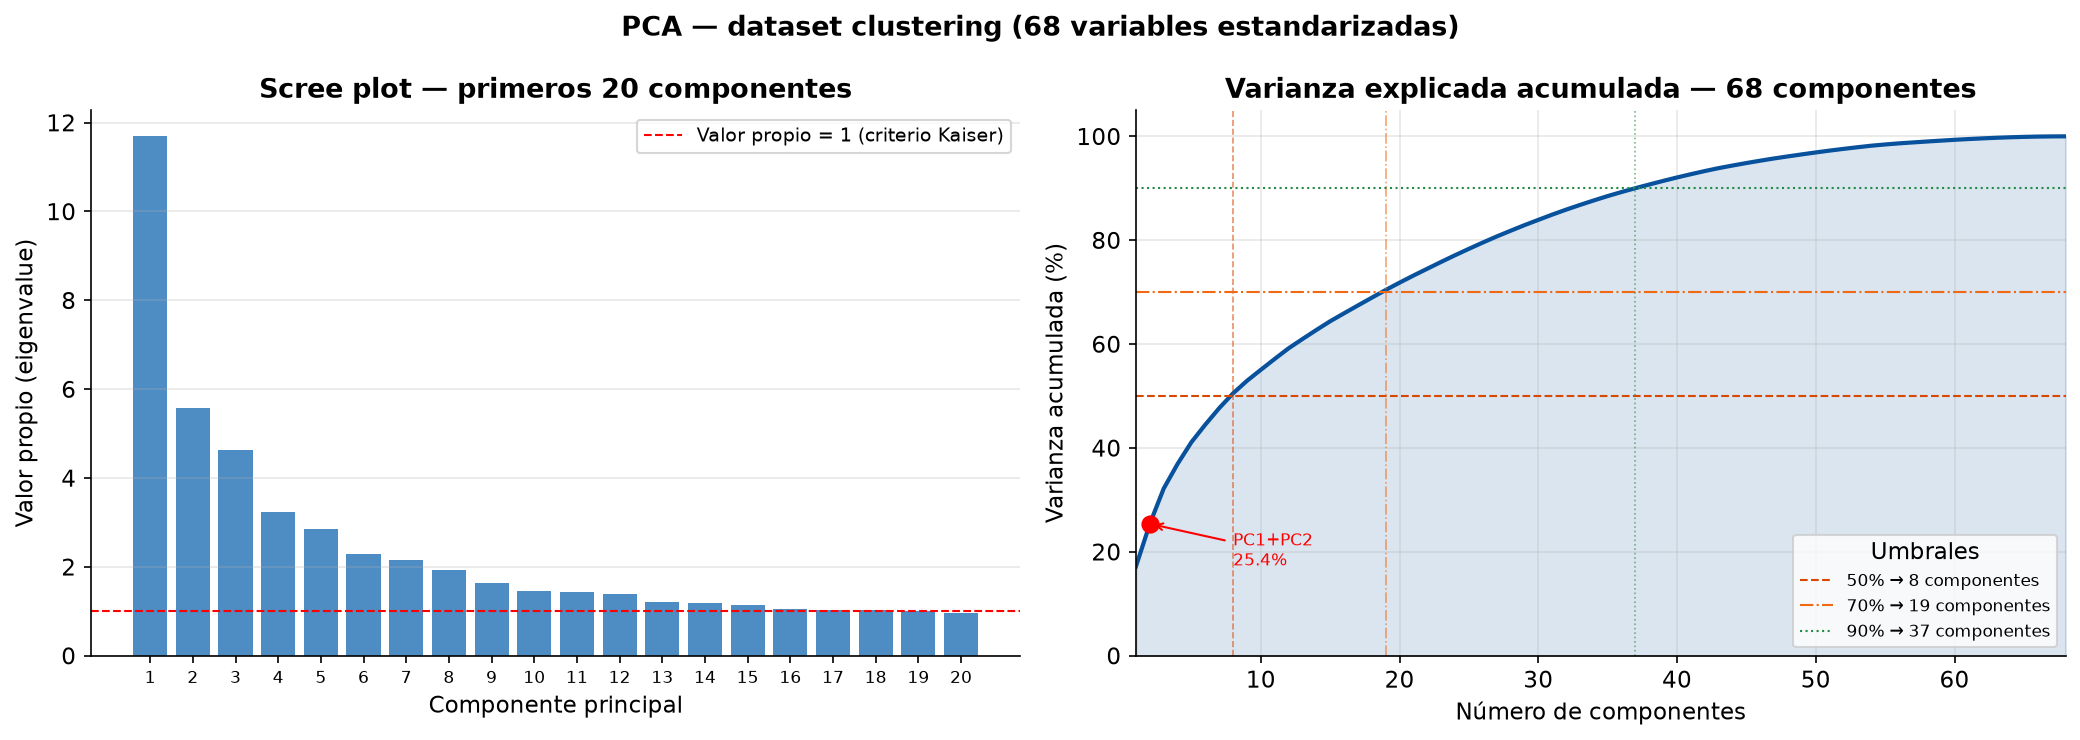

Figura guardada: outputs/fig18_pca_scree_varianza.png


In [24]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Cargar matriz estandarizada
X_pca_full = pd.read_parquet(config.DATA_DIR / "B01_MATRIZ_CLUSTERING.parquet")
X_pca_arr  = X_pca_full[config.CLUSTER_VARS_FINAL].values

# PCA completo sobre las 68 dimensiones
print("Ejecutando PCA completo (68 componentes)...")
pca_full = PCA(n_components=68, random_state=42)
pca_full.fit(X_pca_arr)

var_exp     = pca_full.explained_variance_ratio_
var_acum    = np.cumsum(var_exp)
eigenvalues = pca_full.explained_variance_

# ── Tabla 20 primeros componentes ────────────────────────────────────────
print("\nTABLA PCA — VARIANZA EXPLICADA (primeros 20 componentes)")
print("=" * 65)
print(f"{'CP':>4}  {'Valor propio':>13}  {'Varianza (%)':>13}  {'Acumulada (%)':>14}")
print("-" * 65)
for i in range(20):
    print(f"{i+1:>4}  {eigenvalues[i]:>13.4f}  "
          f"{var_exp[i]*100:>12.2f}%  "
          f"{var_acum[i]*100:>13.2f}%")
print("-" * 65)

# ── Hitos de varianza acumulada ───────────────────────────────────────────
print("\nHITOS DE VARIANZA ACUMULADA:")
for umbral in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]:
    n_comp = np.argmax(var_acum >= umbral) + 1
    print(f"  {umbral*100:.0f}% de varianza explicada: {n_comp} componentes")

print(f"\n  PC1 + PC2 (visualización): {var_acum[1]*100:.2f}%")
print(f"  PC1 a PC5               : {var_acum[4]*100:.2f}%")
print(f"  PC1 a PC10              : {var_acum[9]*100:.2f}%")
print(f"  PC1 a PC20              : {var_acum[19]*100:.2f}%")

# ── Figura — Scree plot + varianza acumulada ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 21), eigenvalues[:20],
            color="#2171b5", alpha=0.8, edgecolor="none")
axes[0].axhline(y=1, color="red", linestyle="--",
                linewidth=1, label="Valor propio = 1 (criterio Kaiser)")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Valor propio (eigenvalue)")
axes[0].set_title("Scree plot — primeros 20 componentes",
                  fontweight="bold")
axes[0].set_xticks(range(1, 21))
axes[0].tick_params(axis="x", labelsize=8)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, 69), var_acum * 100,
             color="#08519c", linewidth=2)
axes[1].fill_between(range(1, 69), var_acum * 100,
                     alpha=0.15, color="#08519c")

for umbral, color, ls in [(0.50, "#d94801", "--"),
                           (0.70, "#f16913", "-."),
                           (0.90, "#238b45", ":")]:
    n_comp = np.argmax(var_acum >= umbral) + 1
    axes[1].axhline(y=umbral*100, color=color,
                    linestyle=ls, linewidth=1,
                    label=f"{umbral*100:.0f}% → {n_comp} componentes")
    axes[1].axvline(x=n_comp, color=color,
                    linestyle=ls, linewidth=0.8, alpha=0.6)

axes[1].scatter([2], [var_acum[1]*100], color="red", zorder=5, s=60)
axes[1].annotate(f"PC1+PC2\n{var_acum[1]*100:.1f}%",
                 xy=(2, var_acum[1]*100),
                 xytext=(8, var_acum[1]*100 - 8),
                 fontsize=8, color="red",
                 arrowprops={"arrowstyle": "->", "color": "red", "lw": 1})

axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].set_title("Varianza explicada acumulada — 68 componentes",
                  fontweight="bold")
axes[1].set_xlim(1, 68)
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=8, title="Umbrales")
axes[1].grid(alpha=0.3)

fig.suptitle("PCA — dataset clustering (68 variables estandarizadas)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig18_pca_scree_varianza.png",
            bbox_inches="tight")
plt.show()
print("Figura guardada: outputs/fig18_pca_scree_varianza.png")

In [25]:
# Resumen ejecutivo PCA para la tesis
print("RESUMEN EJECUTIVO — DECISIÓN PCA")
print("=" * 55)
print(f"  Dimensiones originales           : 68 variables")
print(f"  Componentes con valor propio > 1 : "
      f"{(eigenvalues > 1).sum()} (criterio Kaiser)")
print(f"  Varianza PC1 + PC2               : {var_acum[1]*100:.2f}%")
print(f"  Varianza PC1 a PC10              : {var_acum[9]*100:.2f}%")
print(f"  Componentes para 90% varianza    : "
      f"{np.argmax(var_acum >= 0.90) + 1}")
print(f"  Componentes para 95% varianza    : "
      f"{np.argmax(var_acum >= 0.95) + 1}")
print()
print("  DECISIÓN: No aplicar PCA como preproceso del clustering.")
print("  Reducir a 10 componentes descartaría el 44,95% de la")
print("  varianza. Reducir a 20 componentes descartaría el 28,18%.")
print("  El PCA se usa exclusivamente para visualización (PC1+PC2).")
print("  Referencia: Jolliffe y Cadima (2016).")

RESUMEN EJECUTIVO — DECISIÓN PCA
  Dimensiones originales           : 68 variables
  Componentes con valor propio > 1 : 19 (criterio Kaiser)
  Varianza PC1 + PC2               : 25.39%
  Varianza PC1 a PC10              : 55.05%
  Componentes para 90% varianza    : 37
  Componentes para 95% varianza    : 46

  DECISIÓN: No aplicar PCA como preproceso del clustering.
  Reducir a 10 componentes descartaría el 44,95% de la
  varianza. Reducir a 20 componentes descartaría el 28,18%.
  El PCA se usa exclusivamente para visualización (PC1+PC2).
  Referencia: Jolliffe y Cadima (2016).


## 2.9 Conclusiones del EDA

El análisis exploratorio sobre los 797.161 contribuyentes del universo 
analítico permite establecer las siguientes conclusiones para el pipeline 
de clustering:

In [26]:
# Tabla resumen del EDA
resumen = {
    "Universo de contribuyentes"          : f"{config.N_UNIVERSE:,}",
    "Variables en dataset integrado"      : "263",
    "Variables núcleo originales"         : "80",
    "Eliminadas por redundancia"          : "12",
    "Núcleo definitivo de clustering"     : f"{len(CLUSTER_VARS_FINAL)}",
    "Variables con log(x+1)"             : f"{len([v for v in CLUSTER_VARS_FINAL if v not in config.NO_LOG_VARS])}",
    "Variables directas a z-score"        : f"{len([v for v in CLUSTER_VARS_FINAL if v in config.NO_LOG_VARS])}",
    "Winsorizaciones aplicadas"           : "5 variables",
    "Pares residuales |r| ≥ 0.80"        : "13 (económicamente justificados)",
    "Pares residuales |r| ≥ 0.90"        : "2 (retenidos deliberadamente)",
    "Cobertura F01 (perfil IVA)"         : "792.750 (99.45%)",
    "Cobertura F02 (renta)"              : "761.711 (95.55%)",
    "Con recaudación efectiva F05"        : "505.178 (63.37%)",
    "Sin recaudación — omisión cero F06" : "277.359 de 291.983 (95.0%)",
}

print("RESUMEN EDA — DATASET ANALÍTICO INTEGRADO")
print("=" * 55)
for k, v in resumen.items():
    print(f"  {k:<45s} {v}")

RESUMEN EDA — DATASET ANALÍTICO INTEGRADO
  Universo de contribuyentes                    797,161
  Variables en dataset integrado                263
  Variables núcleo originales                   80
  Eliminadas por redundancia                    12
  Núcleo definitivo de clustering               68
  Variables con log(x+1)                        28
  Variables directas a z-score                  40
  Winsorizaciones aplicadas                     5 variables
  Pares residuales |r| ≥ 0.80                   13 (económicamente justificados)
  Pares residuales |r| ≥ 0.90                   2 (retenidos deliberadamente)
  Cobertura F01 (perfil IVA)                    792.750 (99.45%)
  Cobertura F02 (renta)                         761.711 (95.55%)
  Con recaudación efectiva F05                  505.178 (63.37%)
  Sin recaudación — omisión cero F06            277.359 de 291.983 (95.0%)


### Hallazgos principales

**Estructura del universo:** el 95% de los contribuyentes sin 
recaudación registrada en F05 tiene tasa de omisión cero según F06 — 
declararon correctamente pero con IVA neto cero (tarifa 0%, saldo a 
favor, o actividad no gravada en el período). Solo el 5% combina 
ausencia de pago con omisión parcial o total, configurando el grupo 
de mayor interés para el análisis de resistencia fiscal.

**Asimetría extrema:** las variables monetarias de F01 presentan 
skewness entre 100 y 356 — reflejo de la distribución altamente 
concentrada de la actividad económica formal en Ecuador. La 
transformación log(x+1) es obligatoria antes de cualquier 
estandarización para que el clustering no esté dominado por los 
grandes contribuyentes.

**Cobertura interfuente:** todos los cruces interfuente previstos 
(F05×F01, F04×F01, F07×F01) tienen cobertura suficiente para 
construir ratios de coherencia. La cobertura mínima es 56.3% 
para el cruce F07×F01 (retenciones recibidas), lo que da base 
empírica suficiente para las variables de F07 en el clustering.

**Próximo paso:** preparación del dataset de clustering — 
imputación de missings, winsorización, transformación log(x+1) 
y estandarización z-score — seguido del modelado con K-means, 
clustering jerárquico Ward y DBSCAN.

In [27]:
# Guardar lista definitiva también como variable Python para el siguiente notebook
import json

# Reescribir JSON final completo
output_final = {
    "CLUSTER_VARS_FINAL": CLUSTER_VARS_FINAL,
    "ELIMINADAS_REDUNDANCIA": list(eliminadas.keys()) + list(eliminadas_final.keys()),
    "MOVIDAS_A_CHARAC": A_CHARAC + ["prop_pagos_tardios_f05"],
    "NO_LOG_VARS_EN_CLUSTER": [v for v in CLUSTER_VARS_FINAL if v in config.NO_LOG_VARS],
    "LOG_VARS_EN_CLUSTER": [v for v in CLUSTER_VARS_FINAL if v not in config.NO_LOG_VARS],
    "n_vars_originales": 80,
    "n_vars_eliminadas": len(eliminadas) + len(eliminadas_final),
    "n_vars_definitivas": len(CLUSTER_VARS_FINAL),
}

ruta_json = config.DATA_DIR / "cluster_vars_final.json"
with open(ruta_json, "w", encoding="utf-8") as f:
    json.dump(output_final, f, indent=2, ensure_ascii=False)

print("EDA completado y resultados guardados.")
print(f"JSON: {ruta_json}")
print(f"\nNúcleo definitivo: {len(CLUSTER_VARS_FINAL)} variables")
print(f"  Con log(x+1)   : {len(output_final['LOG_VARS_EN_CLUSTER'])}")
print(f"  Sin log        : {len(output_final['NO_LOG_VARS_EN_CLUSTER'])}")
print(f"\nEl siguiente notebook es 03_preparacion_clustering.ipynb")

EDA completado y resultados guardados.
JSON: D:\inf_sri_hist3\z_CLUSTER\data\cluster_vars_final.json

Núcleo definitivo: 68 variables
  Con log(x+1)   : 28
  Sin log        : 40

El siguiente notebook es 03_preparacion_clustering.ipynb


### Verificaciones adicionales

In [28]:
import importlib
importlib.reload(config)
print("config.py recargado")
print(f"WINSOR_ANTES_LOG : {config.WINSOR_ANTES_LOG}")
print(f"NO_LOG_VARS      : {len(config.NO_LOG_VARS)} variables")

config.py recargado
WINSOR_ANTES_LOG : {'ratio_anul_emit': 0.9286, 'ratio_pago_causado': 96.7939, 'ratio_saldo_iva_vtas': 31.4766}
NO_LOG_VARS      : 45 variables


In [29]:
import sys, os
ROOT = r"D:\inf_sri_hist3\z_CLUSTER"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import config
import importlib
importlib.reload(config)

import pandas as pd
import numpy as np

# ── Ruta a la matriz original (antes de eliminar redundantes) ──────────────
# Necesitamos la matriz CON las variables eliminadas para calcular la corr.
# La reconstruimos desde el Parquet completo + preparación.
# ──────────────────────────────────────────────────────────────────────────

# Variables eliminadas por redundancia (documentadas en 02_EDA.ipynb)
ELIMINADAS_REDUNDANCIA = {
    "tot_v_grav_brt"       : ("tot_v_grav_nta",        "r=0.997 — redundancia contable (bruta vs. neta)"),
    "tot_imp_v_grav"       : ("tot_v_grav_nta",        "r=0.999 — tot_imp = nta × tarifa"),
    "tot_imp_c_cdc"        : ("tot_c_grav_cdc_nta",    "r=0.9995 — redundancia contable"),
    "tasa_omision_reciente": ("tasa_omision",           "r=0.974 — redundancia temporal (reciente vs. total)"),
    "tasa_tardio_reciente" : ("tasa_tardio",            "r=0.906 — redundancia temporal (reciente vs. total)"),
    "p90_dias_demora"      : ("promedio_dias_demora",   "r=0.969 — redundancia métrica de demora"),
    "n_anos_con_exp_tc_cdc": ("tot_v_tc_cdc",          "r=0.989 — conteo redundante con magnitud"),
    "ratio_saldo_iva_vtas" : ("med_saldo_crt_acum",    "r=0.895 — ratio redundante con magnitud"),
    "ratio_anul_emit"      : ("tot_cve_anulados",       "r=0.893 — capturado por conteo y proporción"),
    "costos_ingresos_avg"  : ("margen_operativo_avg",  "r=-0.895 — inverso matemático del margen"),
    "n_secciones_ciiu"     : ("n_actividades_unicas_ruc","r=0.813 — redundancia clasificación CIIU"),
    "prop_pagos_tardios_f05": ("rezago_medio_f05",     "r=0.911 — redundancia de tardanza (frec. vs. días)"),
}

# ── Recalcular correlaciones Spearman reales desde la matriz ──────────────
print("Cargando dataset para recalcular correlaciones...")
df_full = pd.read_parquet(config.PARQUET_FILE)

# Lista ampliada: CLUSTER_VARS_FINAL + eliminadas
vars_analisis = config.CLUSTER_VARS_FINAL + list(ELIMINADAS_REDUNDANCIA.keys())
vars_presentes = [v for v in vars_analisis if v in df_full.columns]
vars_faltantes  = [v for v in vars_analisis if v not in df_full.columns]
if vars_faltantes:
    print(f"ADVERTENCIA — variables no encontradas en dataset: {vars_faltantes}")

# Transformar igual que en EDA para que la correlación sea la real
df_trans = df_full[vars_presentes].copy()

# Winsorización
for v, umbral in config.WINSOR_ANTES_LOG.items():
    if v in df_trans.columns:
        df_trans[v] = df_trans[v].clip(upper=umbral)
for v, umbral in config.WINSOR_PARAMS.items():
    if v in df_trans.columns:
        df_trans[v] = df_trans[v].clip(upper=umbral)

# Log(x+1) a las variables que lo requieren
for v in config.LOG_VARS_EN_CLUSTER:
    if v in df_trans.columns:
        df_trans[v] = np.log1p(df_trans[v].clip(lower=0))
# También aplicar log a eliminadas que lo requerirían
log_eliminadas = [
    "tot_v_grav_brt", "tot_imp_v_grav", "tot_imp_c_cdc",
    "n_anos_con_exp_tc_cdc", "ratio_saldo_iva_vtas",
    "ratio_anul_emit", "prop_pagos_tardios_f05",
]
for v in log_eliminadas:
    if v in df_trans.columns and v not in config.LOG_VARS_EN_CLUSTER:
        df_trans[v] = np.log1p(df_trans[v].clip(lower=0))

print("Calculando correlaciones Spearman (puede tardar 1-2 minutos)...")
corr_matrix = df_trans[vars_presentes].corr(method="spearman", numeric_only=True)
print("Correlaciones calculadas.")

# ── Construir tabla de salida ─────────────────────────────────────────────
filas = []
for var_elim, (var_ret, razon) in ELIMINADAS_REDUNDANCIA.items():
    if var_elim in corr_matrix.index and var_ret in corr_matrix.columns:
        r = corr_matrix.loc[var_elim, var_ret]
    else:
        r = np.nan
    # Extraer solo el valor numérico de la razón
    r_texto = razon.split(" — ")[0]  # "r=0.997"
    filas.append({
        "Variable eliminada" : var_elim,
        "Variable retenida"  : var_ret,
        "Spearman r"         : round(r, 4),
        "Motivo"             : razon.split(" — ")[1],
    })

tabla = pd.DataFrame(filas).sort_values("Spearman r",
                                         key=lambda x: x.abs(),
                                         ascending=False).reset_index(drop=True)

# ── Imprimir tabla limpia ─────────────────────────────────────────────────
print()
print("VARIABLES ELIMINADAS DEL NÚCLEO DE CLUSTERING POR REDUNDANCIA")
print("Criterio: correlación de Spearman |r| ≥ 0.80 entre variable candidata y retenida")
print("=" * 95)
print(f"{'Variable eliminada':<28}  {'Variable retenida':<26}  {'r':>8}  {'Motivo'}")
print("-" * 95)
for _, row in tabla.iterrows():
    print(f"{row['Variable eliminada']:<28}  {row['Variable retenida']:<26}  "
          f"{row['Spearman r']:>8.4f}  {row['Motivo']}")
print("-" * 95)
print(f"Total variables eliminadas: {len(tabla)} de 80 candidatas originales")
print(f"Núcleo definitivo: {len(config.CLUSTER_VARS_FINAL)} variables")

Cargando dataset para recalcular correlaciones...
Calculando correlaciones Spearman (puede tardar 1-2 minutos)...
Correlaciones calculadas.

VARIABLES ELIMINADAS DEL NÚCLEO DE CLUSTERING POR REDUNDANCIA
Criterio: correlación de Spearman |r| ≥ 0.80 entre variable candidata y retenida
Variable eliminada            Variable retenida                  r  Motivo
-----------------------------------------------------------------------------------------------
tot_imp_c_cdc                 tot_c_grav_cdc_nta            0.9995  redundancia contable
tot_imp_v_grav                tot_v_grav_nta                0.9993  tot_imp = nta × tarifa
tot_v_grav_brt                tot_v_grav_nta                0.9968  redundancia contable (bruta vs. neta)
n_anos_con_exp_tc_cdc         tot_v_tc_cdc                  0.9889  conteo redundante con magnitud
tasa_omision_reciente         tasa_omision                  0.9737  redundancia temporal (reciente vs. total)
p90_dias_demora               promedio_dias_demora